# AUTOR

Lucas Gallego Bravo


# 1.Installs e imports

## 1.1 Installs

In [ ]:
pip install matplotlib seaborn pandas numpy scikit-learn tensorflow catboost pytorch-tabnet --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00


## 1.2 Imports

In [ ]:
import os
import shutil
import random
from math import pi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation, LGBMClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.tab_model import TabNetRegressor
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow import keras
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

# 2.Carga de los datos

Primero cargamos los datasets que vamos a utilizar, en este caso el dataset con todos los datos del GP de España y el de Monaco:

In [ ]:
df_original = pd.read_csv("Spain.csv")
df_monaco = pd.read_csv("Monaco_test.csv")

# 3.EDA (Exploratory Data Analysis)

## 3.1 Información básica del dataset

Primero describiremos nuestro dataset para ver todas las columnas y la información que contienen:

In [ ]:
print("Shape del dataset:", df_original.shape)
df_original.info()
df_original.describe()

Shape del dataset: (10262, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10262 entries, 0 to 10261
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time                10262 non-null  object 
 1   Driver              10262 non-null  object 
 2   DriverNumber        10262 non-null  int64  
 3   LapTime             8289 non-null   object 
 4   LapNumber           10262 non-null  float64
 5   Stint               10249 non-null  float64
 6   PitOutTime          2226 non-null   object 
 7   PitInTime           2221 non-null   object 
 8   Sector1Time         8554 non-null   object 
 9   Sector2Time         10194 non-null  object 
 10  Sector3Time         10104 non-null  object 
 11  Sector1SessionTime  8542 non-null   object 
 12  Sector2SessionTime  10194 non-null  object 
 13  Sector3SessionTime  10104 non-null  object 
 14  SpeedI1             10247 non-null  float64
 15  SpeedI2             10

,DriverNumber,LapNumber,Stint,SpeedI1,SpeedI2,SpeedFL,SpeedST,TyreLife,TrackStatus,Position,LapTime(s),CircuitDistance,Year
count,10262.000000,10262.000000,10249.000000,10247.000000,10218.000000,8040.000000,10250.000000,10237.000000,10249.000000,0.0,8289.000000,1.026200e+04,10262.000000
mean,28.358702,12.715358,3.103522,231.553723,239.289978,270.046393,268.215610,6.657810,4.185189,NaN,94.368809,4.657000e+00,2022.478951
std,24.479911,8.253757,1.612947,52.775548,52.294365,39.774297,58.520262,5.057932,46.937242,NaN,18.919935,6.084319e-13,1.718492
min,1.000000,1.000000,1.000000,12.000000,33.000000,2.000000,33.000000,1.000000,1.000000,NaN,71.383000,4.657000e+00,2020.000000
25%,10.000000,6.000000,2.000000,195.000000,205.000000,272.000000,234.000000,3.000000,1.000000,NaN,80.314000,4.657000e+00,2021.000000
50%,20.000000,12.000000,3.000000,255.000000,255.000000,278.000000,295.000000,5.000000,1.000000,NaN,84.973000,4.657000e+00,2023.000000
75%,44.000000,18.000000,4.000000,274.000000,277.000000,283.000000,310.000000,10.000000,1.000000,NaN,107.065000,4.657000e+00,2024.000000
max,99.000000,42.000000,8.000000,296.000000,315.000000,299.000000,342.000000,28.000000,2671.000000,NaN,162.607000,4.657000e+00,2025.000000


Ahora veremos que forma tiene el dataset de Monaco

In [ ]:
print("Shape del dataset:", df_monaco.shape)
df_monaco.info()
df_monaco.describe()

Shape del dataset: (1279, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time                1279 non-null   object 
 1   Driver              1279 non-null   object 
 2   DriverNumber        1279 non-null   int64  
 3   LapTime             1031 non-null   object 
 4   LapNumber           1279 non-null   float64
 5   Stint               1279 non-null   float64
 6   PitOutTime          279 non-null    object 
 7   PitInTime           279 non-null    object 
 8   Sector1Time         1260 non-null   object 
 9   Sector2Time         1247 non-null   object 
 10  Sector3Time         1042 non-null   object 
 11  Sector1SessionTime  1260 non-null   object 
 12  Sector2SessionTime  1247 non-null   object 
 13  Sector3SessionTime  1042 non-null   object 
 14  SpeedI1             1266 non-null   float64
 15  SpeedI2             1248 

,DriverNumber,LapNumber,Stint,SpeedI1,SpeedI2,SpeedFL,SpeedST,TyreLife,TrackStatus,Position,LapTime(s),CircuitDistance,Year
count,1279.000000,1279.000000,1279.000000,1266.000000,1248.000000,1000.000000,1255.000000,1279.000000,1279.000000,0.0,1031.000000,1.279000e+03,1279.000000
mean,29.136826,12.443315,2.844410,175.305687,173.945513,265.210000,253.780876,3.566849,7.827209,NaN,88.264702,3.337000e+00,2024.010164
std,23.759276,7.797899,1.750483,44.827546,30.056380,16.297838,32.605549,2.202935,30.702862,NaN,15.576798,7.552470e-15,0.816912
min,1.000000,1.000000,1.000000,45.000000,38.000000,106.000000,88.000000,1.000000,1.000000,NaN,69.954000,3.337000e+00,2023.000000
25%,11.000000,6.000000,1.000000,148.000000,157.750000,267.000000,244.000000,2.000000,1.000000,NaN,72.512500,3.337000e+00,2023.000000
50%,22.000000,11.000000,2.000000,183.000000,179.000000,269.000000,262.000000,3.000000,1.000000,NaN,88.741000,3.337000e+00,2024.000000
75%,44.000000,18.000000,4.000000,217.000000,201.000000,270.000000,279.000000,5.000000,1.000000,NaN,99.691000,3.337000e+00,2025.000000
max,87.000000,34.000000,8.000000,227.000000,215.000000,274.000000,286.000000,13.000000,251.000000,NaN,146.829000,3.337000e+00,2025.000000


## 3.2 Vueltas registradas por año

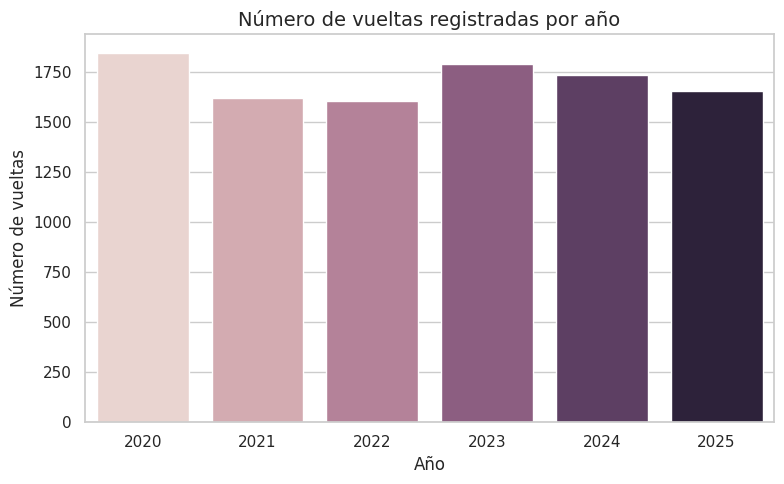

In [ ]:
sns.set(style="whitegrid")

# Conteo de vueltas por año
laps_per_year = df_original['Year'].value_counts().sort_index()

# Gráfico de barras
plt.figure(figsize=(8, 5))
sns.barplot(
    x=laps_per_year.index,
    y=laps_per_year.values,
    hue=laps_per_year.index,
    legend=False)
plt.title("Número de vueltas registradas por año", fontsize=14)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Número de vueltas", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.3 Distribución de todos los tiempos por vuelta

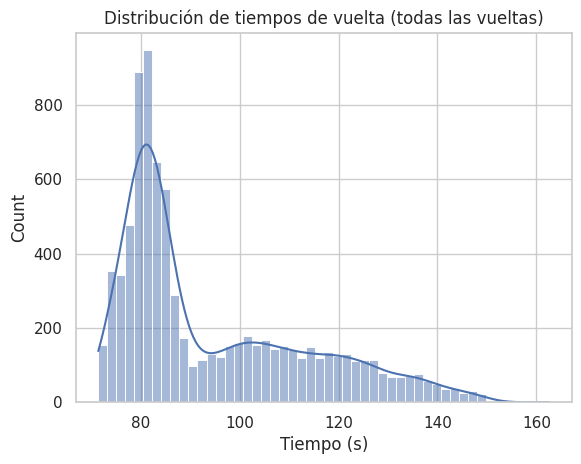

In [ ]:
# Histograma de tiempos de vuelta
sns.histplot(df_original['LapTime(s)'], bins=50, kde=True)
plt.title('Distribución de tiempos de vuelta (todas las vueltas)')
plt.xlabel('Tiempo (s)')
plt.show()

## 3.4 LapTime según el tipo de nuumático empleado

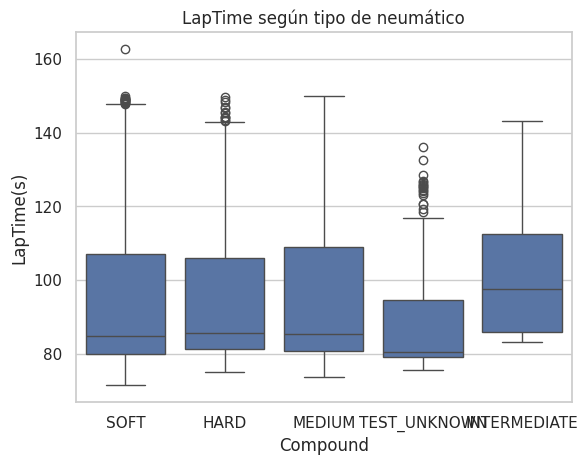

In [ ]:
# Boxplots por tipo de neumático
sns.boxplot(data=df_original, x='Compound', y='LapTime(s)')
plt.title("LapTime según tipo de neumático")
plt.show()

## 3.5 Comparación de tiempos por año

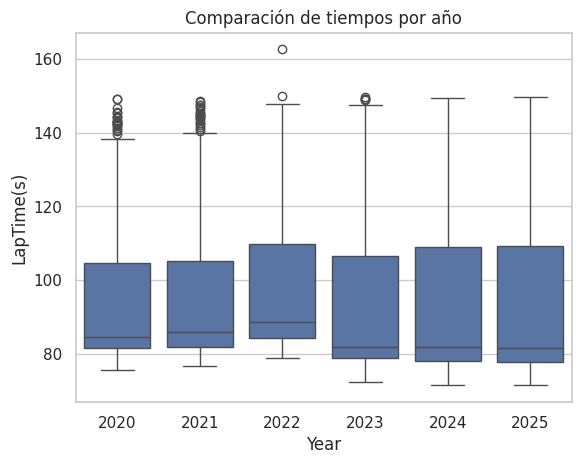

In [ ]:
# Comparativa por año
sns.boxplot(data=df_original, x='Year', y='LapTime(s)')
plt.title("Comparación de tiempos por año")
plt.show()

## 3.6 Número de vueltas por piloto

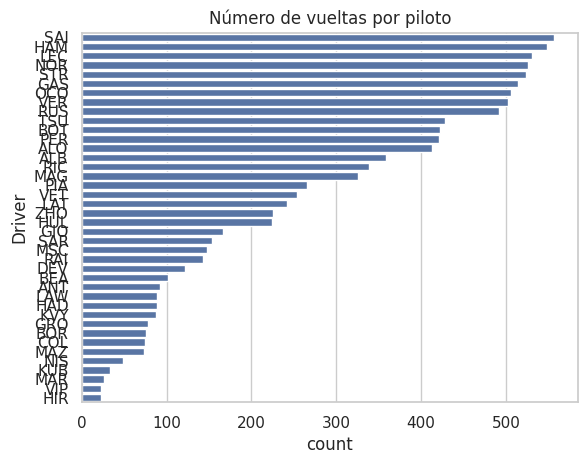

In [ ]:
# Distribución de vueltas por piloto
sns.countplot(
    data=df_original,
    y='Driver',
    order=df_original['Driver'].value_counts().index)
plt.title("Número de vueltas por piloto")
plt.show()

##3.7 LapTime según stint y neumático

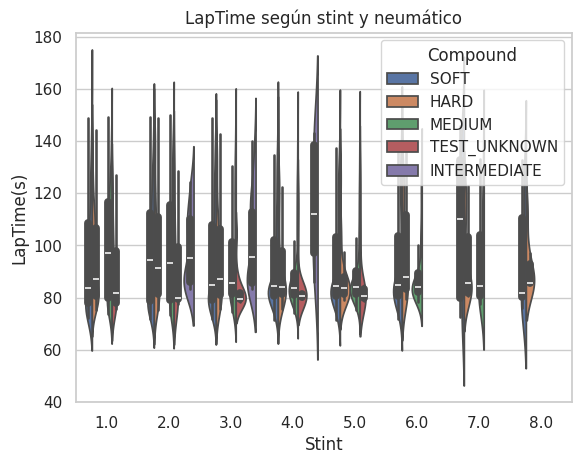

In [ ]:
# Análisis por Stint (tanda de vueltas)
sns.violinplot(
    data=df_original,
    x='Stint',
    y='LapTime(s)',
    hue='Compound',
    split=True)
plt.title("LapTime según stint y neumático")
plt.show()

## 3.8 Relación entre velocidad máxima y tiempo de vuelta

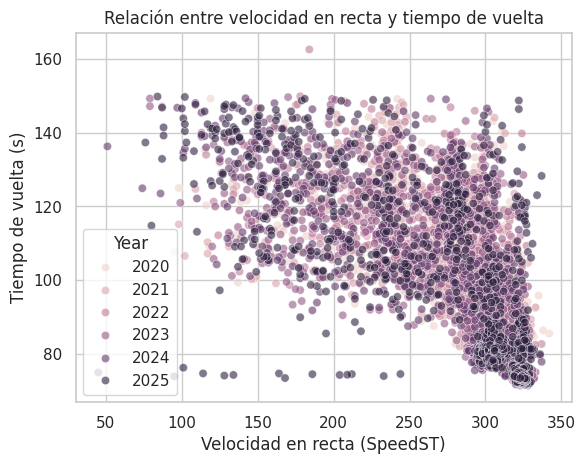

In [ ]:
# Relación entre velocidad máxima (SpeedFL o SpeedST) y tiempo de vuelta
sns.scatterplot(
    data=df_original,
    x='SpeedST',
    y='LapTime(s)',
    hue='Year',
    alpha=0.6)
plt.title("Relación entre velocidad en recta y tiempo de vuelta")
plt.xlabel("Velocidad en recta (SpeedST)")
plt.ylabel("Tiempo de vuelta (s)")
plt.show()

## 3.9 Evolución de las vueltas dentro de la sesión

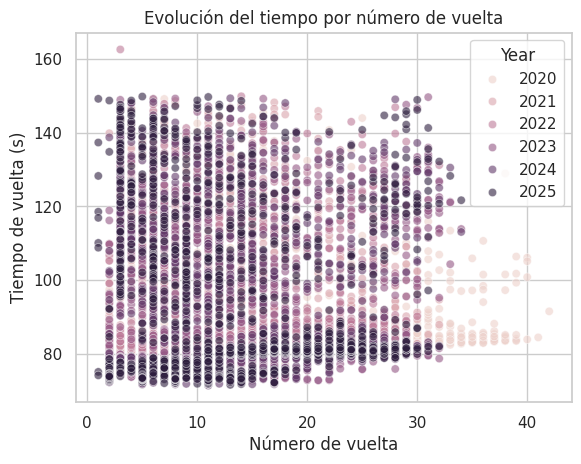

In [ ]:
# Evolución de las vueltas dentro de la sesión (LapNumber vs. LapTime)
sns.scatterplot(
    data=df_original,
    x='LapNumber',
    y='LapTime(s)',
    hue='Year',
    alpha=0.6)
plt.title("Evolución del tiempo por número de vuelta")
plt.xlabel("Número de vuelta")
plt.ylabel("Tiempo de vuelta (s)")
plt.show()

## 3.10 Heatmap de correlación entre variables numéricas

Text(0.5, 1.0, 'Matriz de Correlación')

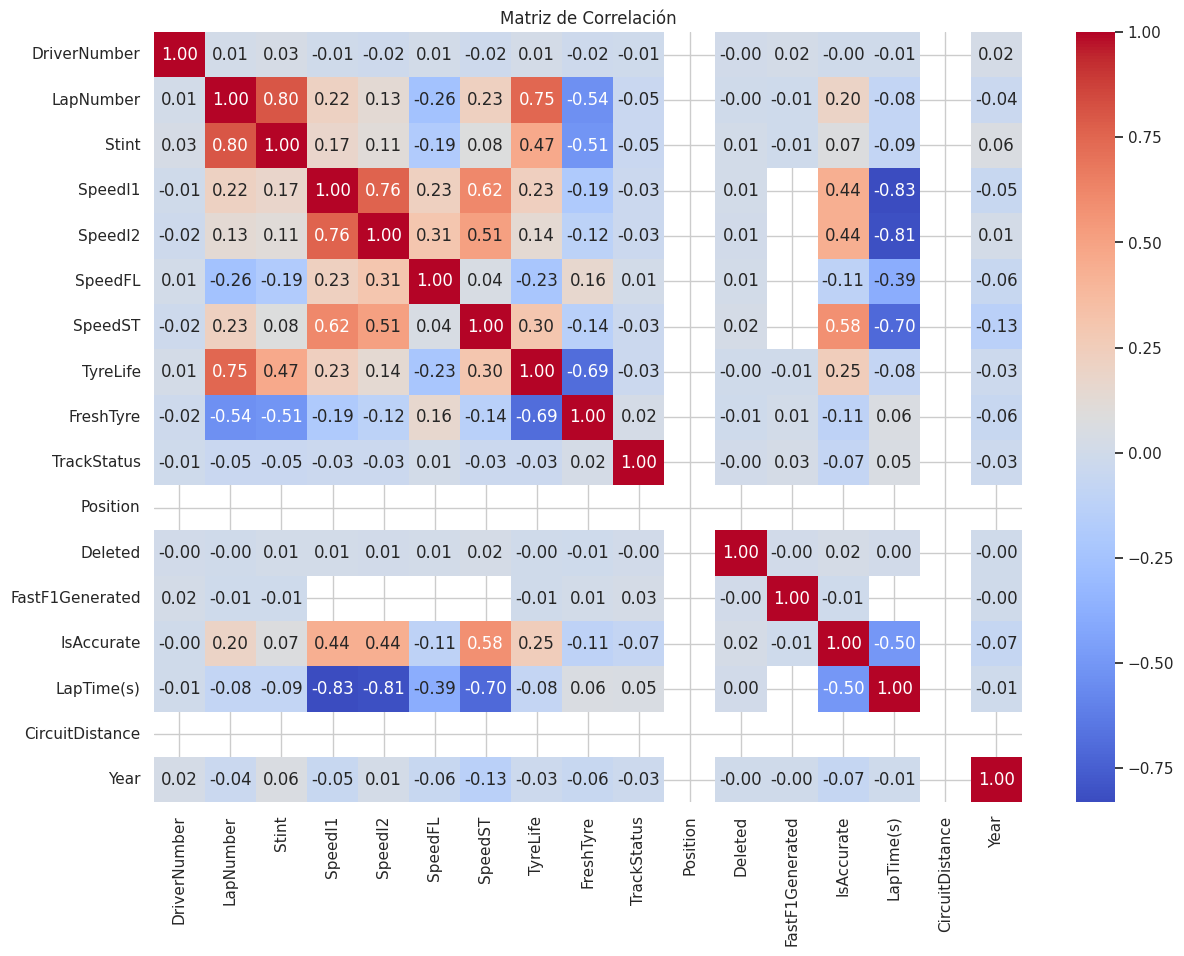

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_original.corr(
        numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm")
plt.title("Matriz de Correlación")

##3.11 Valores faltantes

<Axes: >

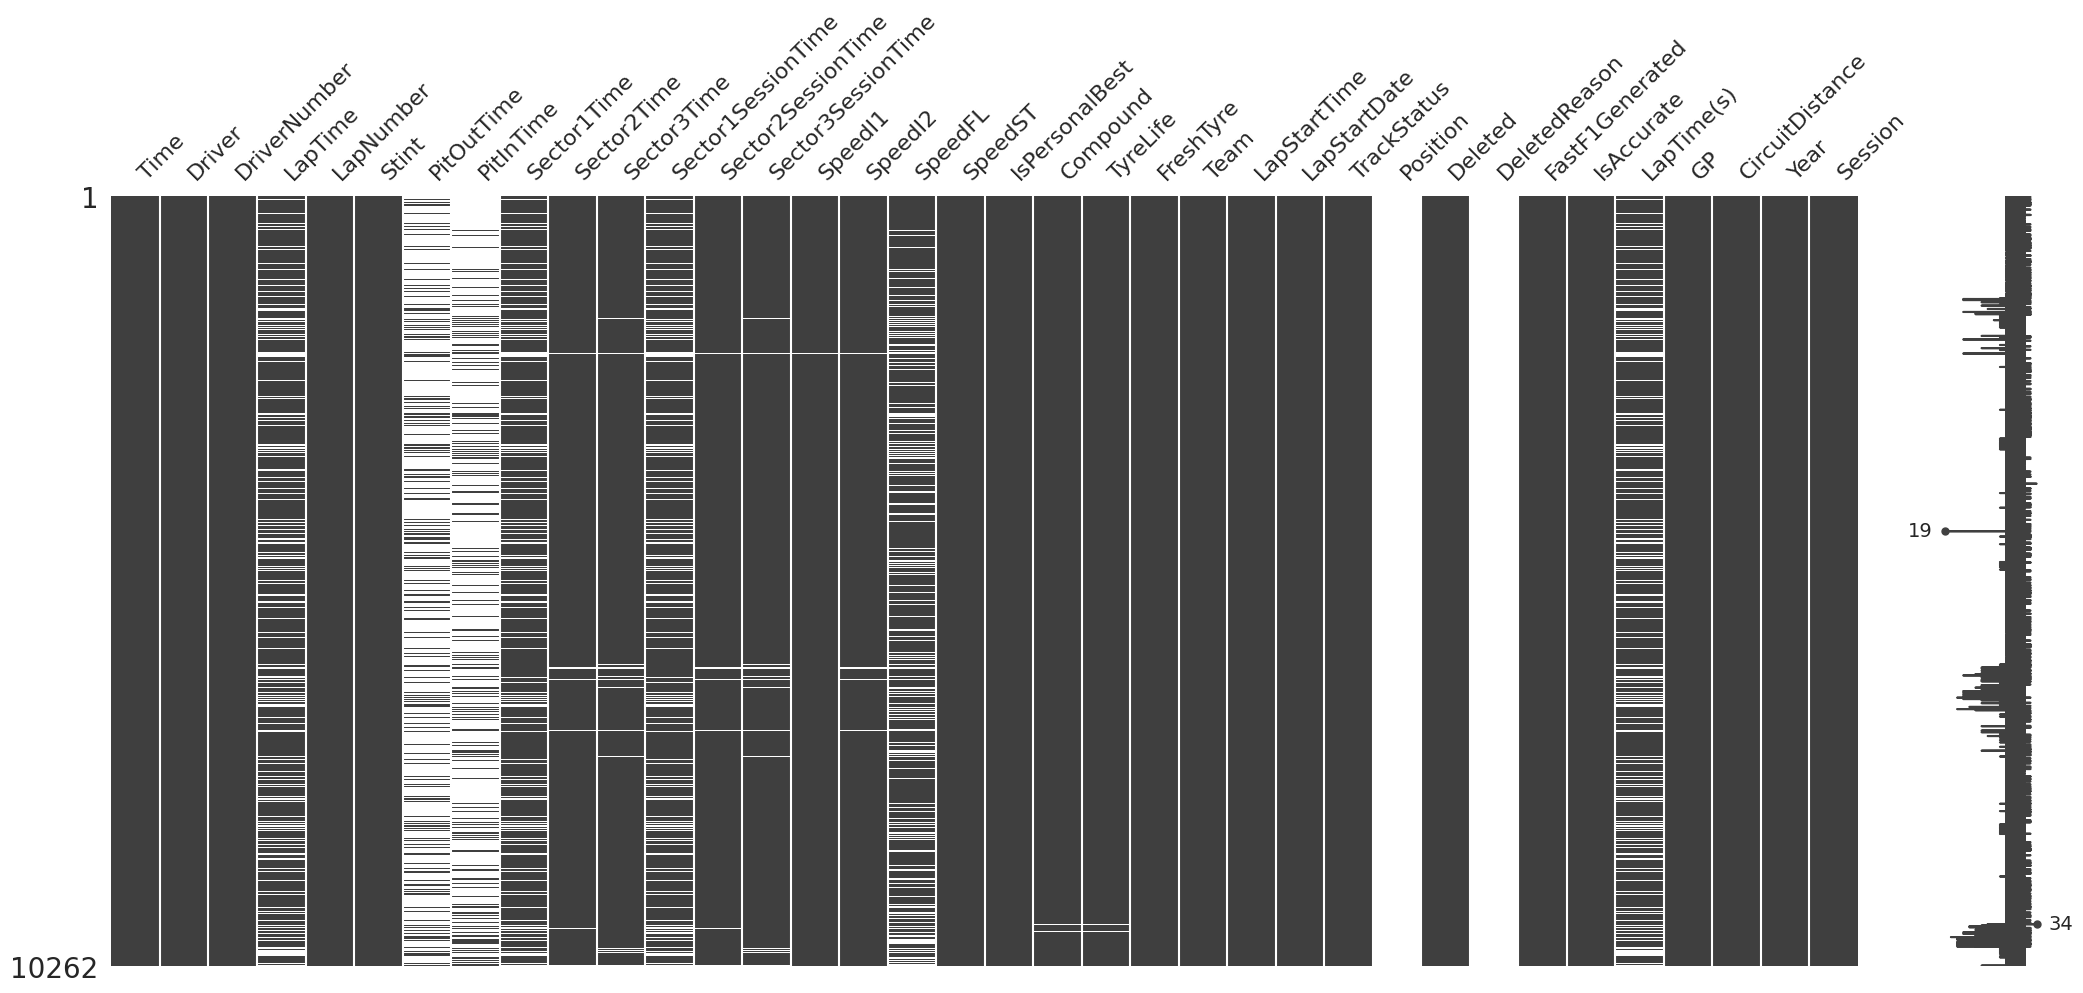

In [ ]:
msno.matrix(df_original)

Como podemos observar, hay varias relaciones interesantes entre las columnas de nuestro dataset, al mismo tiempo, hay algunos valores faltantes como se puede apreciar en el último grafo y columnas que directamente no tienen ningún valor. Toda esta información se utilizará para el preproceso general y el específico de cada una de las tareas.

# 4.Preproceso general

A continuación haremos un primer preproceso general el cual todas las tareas a continuación necesitan para poder funcionar correctamente, como la eliminación de columnas vacías, o la eliminación/modificación de valores nulos en otras.

Primero vamos a eliminar las columnas de nuestro dataset que se encuentran totalmente vacías o que no son relevantes para las tareas que vamos a realizar, para ello primero creamos una lista con todos los nombres de las columnas a eliminar.

Cabe destacar que la columna 'LapTime' es eliminada ya que anteriormente se ha creado una columna idéntica que contiene los datos en segundos.

In [ ]:
# Lista de columnas a eliminar
columns_to_drop = [
    'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
    'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
    'PitOutTime', 'PitInTime', 'LapStartDate', 'FastF1Generated',
    'IsAccurate', 'Deleted', 'DeletedReason', 'Position', 'Driver'
]

Una vez seleccionadas, las eliminamos:

In [ ]:
df_original.drop(columns=columns_to_drop, inplace=True)
df_monaco.drop(columns=columns_to_drop, inplace=True)

Ahora transformamos las columnas categóricas a columnas numéricas utilizando un encoder:

In [ ]:
categorical_cols = [
    'DriverNumber',
    'Compound',
    'Team',
    'Session',
    'TrackStatus',
    'GP']

In [ ]:
# ===== NORMALIZAR =====
for col in categorical_cols:

    # Rellenar NaN
    df_original[col] = df_original[col].fillna(-1)
    df_monaco[col] = df_monaco[col].fillna(-1)

    # Para columnas numéricas categóricas
    if col in ['DriverNumber', 'TrackStatus']:

        df_original[col] = df_original[col].astype(int)
        df_monaco[col] = df_monaco[col].astype(int)

    # Convertir todo a string
    df_original[col] = df_original[col].astype(str)
    df_monaco[col] = df_monaco[col].astype(str)

In [ ]:
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

In [ ]:
encoder.fit(df_original[categorical_cols])

OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

In [ ]:
df_original[categorical_cols] = encoder.transform(
    df_original[categorical_cols]
)

# Aplica a Monaco
df_monaco[categorical_cols] = encoder.transform(
    df_monaco[categorical_cols]
)

También debemos convertir las columnas de tipo booleano a enteros:

In [ ]:
df_original['IsPersonalBest'] = df_original['IsPersonalBest'].map({
                                                                  True: 1, False: 0})
df_original['FreshTyre'] = df_original['FreshTyre'].astype(int)

In [ ]:
df_monaco['IsPersonalBest'] = df_monaco['IsPersonalBest'].map({
                                                                  True: 1, False: 0})
df_monaco['FreshTyre'] = df_monaco['FreshTyre'].astype(int)

Eliminamos filas de nuestro dataset que no tengan ningún tiempo de vuelta:

In [ ]:
df_original.dropna(subset=['LapTime(s)'], inplace=True)
df_monaco.dropna(subset=['LapTime(s)'], inplace=True)

Viendo la relación que tienen algunas de las columnas de nuestro dataset, se ha decidido añadir las siguientes features a nuestro dataset, con el fin de ayudar al entrenamiento de los modelos:

In [ ]:
# Diferencia entre velocidades
df_original["SpeedDiff"] = df_original["SpeedST"] - df_original["SpeedFL"]
# Relación desgaste de neumático
df_original["TyreAgeRatio"] = df_original["TyreLife"] / \
    (df_original["Stint"] + 1e-3)
# Velocidad normalizada por vida de neumático
df_original["SpeedFL_norm"] = df_original["SpeedFL"] / \
    (df_original["TyreLife"] + 1e-3)

In [ ]:
# Diferencia entre velocidades
df_monaco["SpeedDiff"] = df_monaco["SpeedST"] - df_monaco["SpeedFL"]
# Relación desgaste de neumático
df_monaco["TyreAgeRatio"] = df_monaco["TyreLife"] / \
    (df_monaco["Stint"] + 1e-3)
# Velocidad normalizada por vida de neumático
df_monaco["SpeedFL_norm"] = df_monaco["SpeedFL"] / \
    (df_monaco["TyreLife"] + 1e-3)

Finalmente verificamos los cambios realizados en nuestro dataset

In [ ]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8289 entries, 2 to 10261
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Time             8289 non-null   object 
 1   DriverNumber     8289 non-null   float64
 2   LapNumber        8289 non-null   float64
 3   Stint            8286 non-null   float64
 4   SpeedI1          8289 non-null   float64
 5   SpeedI2          8289 non-null   float64
 6   SpeedFL          6349 non-null   float64
 7   SpeedST          8289 non-null   float64
 8   IsPersonalBest   8289 non-null   float64
 9   Compound         8289 non-null   float64
 10  TyreLife         8274 non-null   float64
 11  FreshTyre        8289 non-null   int64  
 12  Team             8289 non-null   float64
 13  LapStartTime     8280 non-null   object 
 14  TrackStatus      8289 non-null   float64
 15  LapTime(s)       8289 non-null   float64
 16  GP               8289 non-null   float64
 17  CircuitDistance  8

In [ ]:
df_monaco.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1031 entries, 0 to 1277
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Time             1031 non-null   object 
 1   DriverNumber     1031 non-null   float64
 2   LapNumber        1031 non-null   float64
 3   Stint            1031 non-null   float64
 4   SpeedI1          1031 non-null   float64
 5   SpeedI2          1031 non-null   float64
 6   SpeedFL          994 non-null    float64
 7   SpeedST          1031 non-null   float64
 8   IsPersonalBest   1031 non-null   int64  
 9   Compound         1031 non-null   float64
 10  TyreLife         1031 non-null   float64
 11  FreshTyre        1031 non-null   int64  
 12  Team             1031 non-null   float64
 13  LapStartTime     1031 non-null   object 
 14  TrackStatus      1031 non-null   float64
 15  LapTime(s)       1031 non-null   float64
 16  CircuitDistance  1031 non-null   float64
 17  Year             10

Terminado el preproceso general, ahora tenemos un dos datasets mucho más limpios, con los que se pueden hacer los cambios necesarios en cada tarea (preprocesados específicos de cada tarea) para poder trabajar con ellos.

Los guardamos para no tener que repetir el proceso:

In [ ]:
df_original.to_csv("Spain_preprocesado.csv", index=False)
df_monaco.to_csv("Monaco_preprocesado.csv", index=False)

# 5.Tarea 1 Predicción del tiempo de vuelta

## 5.1 Preprocesado de la tarea

Primero copiaremos el dataset original en otro dataset con el fin de mantener intacto el dataset original y poder usarlo en el resto de tareas.

In [ ]:
df_tarea1 = df_original.copy()

Primero eliminamos las columnas del dataset original que son duplicadas o directamente no aportan nada a la tarea a realizar:

In [ ]:
df_tarea1 = df_tarea1.drop(columns=['Time', 'LapStartTime'])

Posteriormente, eliminamos filas con NaNs en nuestro target (LapTime(s)):

In [ ]:
df_tarea1 = df_tarea1.dropna(subset=['LapTime(s)'])

Ahora, imputamos valores faltantes las columnas numéricas de nuestro dataset que necesitamos para la tarea:

In [ ]:
num_cols = [
    'SpeedI1',
    'SpeedI2',
    'SpeedFL',
    'SpeedST',
    'TyreLife',
    'LapNumber',
    'Stint']
df_tarea1[num_cols] = df_tarea1[num_cols].fillna(df_tarea1[num_cols].median())

Viendo el EDA, vamos a eliminar las vueltas que son claramente anómalas, es decir, que el tiempo en segundos de la vuelta sea mayor de 90:

In [ ]:
df_tarea1 = df_tarea1[df_tarea1["LapTime(s)"] < 90]

Eliminamos filas con valores NaNs en columnas críticas para la tarea:

In [ ]:
df_tarea1 = df_tarea1.dropna(
    subset=[
        "SpeedFL",
        "SpeedST",
        "SpeedDiff",
        "TyreLife"])

Finalmente reiniciamos el index:

In [ ]:
df_tarea1 = df_tarea1.reset_index(drop=True)

Veamos como ha quedado el dataset:

In [ ]:
df_tarea1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4638 entries, 0 to 4637
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DriverNumber     4638 non-null   float64
 1   LapNumber        4638 non-null   float64
 2   Stint            4638 non-null   float64
 3   SpeedI1          4638 non-null   float64
 4   SpeedI2          4638 non-null   float64
 5   SpeedFL          4638 non-null   float64
 6   SpeedST          4638 non-null   float64
 7   IsPersonalBest   4638 non-null   float64
 8   Compound         4638 non-null   float64
 9   TyreLife         4638 non-null   float64
 10  FreshTyre        4638 non-null   int64  
 11  Team             4638 non-null   float64
 12  TrackStatus      4638 non-null   float64
 13  LapTime(s)       4638 non-null   float64
 14  GP               4638 non-null   float64
 15  CircuitDistance  4638 non-null   float64
 16  Year             4638 non-null   int64  
 17  Session       

Como podemos ver, ha bajado en gran medida el número de datos, pero tenemos un dataset completamente limpio y con todos los datos necesarios para nuestra primera tarea.

In [ ]:
df_tarea1.head()

,DriverNumber,LapNumber,Stint,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,...,Team,TrackStatus,LapTime(s),GP,CircuitDistance,Year,Session,SpeedDiff,TyreAgeRatio,SpeedFL_norm
0,15.0,3.0,2.0,276.0,279.0,280.0,309.0,1.0,4.0,3.0,...,14.0,1.0,79.794,0.0,4.657,2020,0.0,29.0,1.499250,93.302233
1,15.0,5.0,2.0,279.0,288.0,280.0,313.0,1.0,4.0,5.0,...,14.0,1.0,79.230,0.0,4.657,2020,0.0,33.0,2.498751,55.988802
2,15.0,7.0,2.0,275.0,205.0,241.0,314.0,0.0,4.0,7.0,...,14.0,1.0,88.116,0.0,4.657,2020,0.0,73.0,3.498251,34.423654
3,15.0,10.0,3.0,276.0,284.0,278.0,310.0,0.0,1.0,2.0,...,14.0,1.0,79.776,0.0,4.657,2020,0.0,32.0,0.666445,138.930535
4,15.0,12.0,3.0,280.0,290.0,281.0,313.0,0.0,1.0,4.0,...,14.0,1.0,79.377,0.0,4.657,2020,0.0,32.0,1.332889,70.232442


Realizamos los mismos cambios para el dataset de Mónaco:

In [ ]:
df_tarea_monac = df_monaco.copy()
df_tarea_monac = df_tarea_monac.drop(columns=['Time', 'LapStartTime'])
df_tarea_monac = df_tarea_monac.dropna(subset=['LapTime(s)'])
df_tarea_monac[num_cols] = df_tarea_monac[num_cols].fillna(df_tarea_monac[num_cols].median())
df_tarea_monac = df_tarea_monac[df_tarea_monac["LapTime(s)"] < 80]
df_tarea_monac = df_tarea_monac.dropna(
    subset=[
        "SpeedFL",
        "SpeedST",
        "SpeedDiff",
        "TyreLife"])
df_tarea_monac = df_tarea_monac.reset_index(drop=True)
df_tarea_monac.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DriverNumber     429 non-null    float64
 1   LapNumber        429 non-null    float64
 2   Stint            429 non-null    float64
 3   SpeedI1          429 non-null    float64
 4   SpeedI2          429 non-null    float64
 5   SpeedFL          429 non-null    float64
 6   SpeedST          429 non-null    float64
 7   IsPersonalBest   429 non-null    int64  
 8   Compound         429 non-null    float64
 9   TyreLife         429 non-null    float64
 10  FreshTyre        429 non-null    int64  
 11  Team             429 non-null    float64
 12  TrackStatus      429 non-null    float64
 13  LapTime(s)       429 non-null    float64
 14  CircuitDistance  429 non-null    float64
 15  Year             429 non-null    int64  
 16  Session          429 non-null    float64
 17  GP              

In [ ]:
df_tarea_monac.head()

,DriverNumber,LapNumber,Stint,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,...,Team,TrackStatus,LapTime(s),CircuitDistance,Year,Session,GP,SpeedDiff,TyreAgeRatio,SpeedFL_norm
0,20.0,2.0,1.0,214.0,196.0,271.0,280.0,1,4.0,2.0,...,8.0,1.0,72.860,3.337,2025,3.0,-1.0,9.0,1.998002,135.432284
1,20.0,4.0,1.0,217.0,205.0,270.0,280.0,1,4.0,4.0,...,8.0,1.0,71.596,3.337,2025,3.0,-1.0,10.0,3.996004,67.483129
2,20.0,6.0,1.0,220.0,199.0,270.0,279.0,0,4.0,6.0,...,8.0,1.0,71.739,3.337,2025,3.0,-1.0,9.0,5.994006,44.992501
3,20.0,10.0,2.0,221.0,207.0,271.0,280.0,1,4.0,10.0,...,8.0,1.0,71.285,3.337,2025,3.0,-1.0,9.0,4.997501,27.097290
4,20.0,13.0,3.0,219.0,211.0,271.0,279.0,1,4.0,2.0,...,8.0,1.0,70.959,3.337,2025,3.0,-1.0,8.0,0.666445,135.432284


In [ ]:
df_tarea_monac.to_csv("Monaco_preprocesado_aug.csv", index=False)

## 5.2 Data Augmentation

Como hemos podido ver, nos hemos quedado con un número algo bajo de datos, por lo que haciendo uso de técnicas de Data Augmentation, vamos a aumentar dicho número.

Como ya hemos limpiado las vueltas anómalas, vamos a utilizar la técnica de interpolación, para de esta forma no añadir ruido que pueda perjudicar al aprendizaje de nuestros modelos.

Para ello primero separamos entre las columnas numéricas y las categóricas de nuestro dataset:

In [ ]:
numeric_features = [
    "LapNumber",
    "Stint",
    "SpeedI1",
    "SpeedI2",
    "SpeedFL",
    "SpeedST",
    "TyreLife",
    "FreshTyre",
    "Year",
    "SpeedDiff",
    "TyreAgeRatio",
    "SpeedFL_norm",
    "IsPersonalBest"]

categorical_features = [
    "Compound", "Session", "TrackStatus",
    "Team", "DriverNumber", "GP"
]

A continuación definimos la función de interpolación con la cual realizaremos el data augmentation, en ella se utilizan los datos de dos filas de la variable X seleccionadas aleatoriamente, para obtener una nueva fila:

In [ ]:
def interpolate_samples_smart(
        X,
        y,
        n_samples,
        categorical_cols,
        random_state=42):
    np.random.seed(random_state)
    X_new, y_new = [], []

    for _ in range(n_samples):
        i, j = np.random.choice(len(X), size=2, replace=False)
        alpha = np.random.rand()

        x_i, x_j = X[i].copy(), X[j].copy()

        x_interp = np.empty_like(x_i)
        for idx in range(len(x_i)):
            if idx in categorical_cols:
                x_interp[idx] = x_i[idx] if np.random.rand() < 0.5 else x_j[idx]
            else:
                x_interp[idx] = x_i[idx] * alpha + x_j[idx] * (1 - alpha)

        y_interp = y[i] * alpha + y[j] * (1 - alpha)

        X_new.append(x_interp)
        y_new.append(y_interp)

    return np.array(X_new), np.array(y_new)

Ahora separamos las columnas de nuestro dataset en X e Y dependiendo de si son el target de la tarea o no:

In [ ]:
y = df_tarea1["LapTime(s)"]
X = df_tarea1.drop(columns=["LapTime(s)"])

Obtenemos el index de las columnas categóricas:

In [ ]:
categorical_indices = [X.columns.get_loc(col) for col in categorical_features]

Una vez separado en X e Y, podemos llamar a la función de interpolación:

In [ ]:
X_aug, y_aug = interpolate_samples_smart(
    X.values, y.values, n_samples=2500, categorical_cols=categorical_indices)

Finalmente concatenamos con la X e Y original:

In [ ]:
X_total = np.vstack([X.values, X_aug])
y_total = np.concatenate([y.values, y_aug])

Creamos un nuevo DF:

In [ ]:
df_tarea1_aug = pd.DataFrame(X_total, columns=X.columns)
df_tarea1_aug["LapTime(s)"] = y_total

Y finalmente restaurmaos los DTypes originales:

In [ ]:
for col in df_tarea1_aug.columns:
    if col in df_tarea1.columns:
        df_tarea1_aug[col] = df_tarea1_aug[col].astype(df_tarea1[col].dtype)

In [ ]:
for col in categorical_features:
    df_tarea1_aug[col] = df_tarea1_aug[col].astype(int)
    df_tarea_monac[col] = df_tarea_monac[col].astype(int)

Veamos como ha quedado el dataset:

In [ ]:
df_tarea1_aug.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7138 entries, 0 to 7137
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DriverNumber     7138 non-null   int64  
 1   LapNumber        7138 non-null   float64
 2   Stint            7138 non-null   float64
 3   SpeedI1          7138 non-null   float64
 4   SpeedI2          7138 non-null   float64
 5   SpeedFL          7138 non-null   float64
 6   SpeedST          7138 non-null   float64
 7   IsPersonalBest   7138 non-null   float64
 8   Compound         7138 non-null   int64  
 9   TyreLife         7138 non-null   float64
 10  FreshTyre        7138 non-null   int64  
 11  Team             7138 non-null   int64  
 12  TrackStatus      7138 non-null   int64  
 13  GP               7138 non-null   int64  
 14  CircuitDistance  7138 non-null   float64
 15  Year             7138 non-null   int64  
 16  Session          7138 non-null   int64  
 17  SpeedDiff     

Como podemos ver, hemos conseguido aumentar el número de datos que teníamos, ahora podemos pasar a dividir este nuevo data frame en los subconjuntos de entrenamiento, validación y test, y comenzar a probar los modelos.

In [ ]:
df_tarea1_aug.to_csv("Spain_preprocesado_aug.csv", index=False)

## 5.3 División Train Test Validación

Como ya se ha mencionado antes, ahora dividiremos el data frame que hemos conseguido en los tres subconjuntos necesarios para nuestra tarea, seguiremos los siguientes porcentajes entrenamiento 70%, validación 15% y test 15% :

In [ ]:
# Primero separamos train del resto
train_df1, temp_df = train_test_split(
    df_tarea1_aug,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

# Luego separamos validación y test
val_df1, test_df1 = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

# Comprobamos tamaños
print(f'Tamaño Train: {len(train_df1)}')
print(f'Tamaño Validación: {len(val_df1)}')
print(f'Tamaño Test: {len(test_df1)}')

Tamaño Train: 4996
Tamaño Validación: 1071
Tamaño Test: 1071


Ahora dividimos los tres subconjuntos es sus X e Y:

In [ ]:
y = df_tarea1_aug['LapTime(s)']
X = df_tarea1_aug.drop(columns=['LapTime(s)'])


y_train1 = train_df1['LapTime(s)']
X_train1 = train_df1.drop(columns=['LapTime(s)'])

y_val1 = val_df1['LapTime(s)']
X_val1 = val_df1.drop(columns=['LapTime(s)'])

y_test1 = test_df1['LapTime(s)']
X_test1 = test_df1.drop(columns=['LapTime(s)'])

Dividimos el dataset de Mónaco en X e Y:

In [ ]:
y_monaco = df_tarea_monac['LapTime(s)']
X_monaco = df_tarea_monac.drop(columns=['LapTime(s)'])
feature_order = X_train1.columns.tolist()
X_monaco= df_tarea_monac.reindex(columns=feature_order)

In [ ]:
# Comprobamos tamaños
print(f'Tamaño Y_Train: {len(y_train1)}')
print(f'Tamaño X_Train: {len(X_train1)}')
print(f'Tamaño Y_Validación: {len(y_val1)}')
print(f'Tamaño X_Validación: {len(X_val1)}')
print(f'Tamaño Y_Test: {len(y_test1)}')
print(f'Tamaño X_Test: {len(X_test1)}')

Tamaño Y_Train: 4996
Tamaño X_Train: 4996
Tamaño Y_Validación: 1071
Tamaño X_Validación: 1071
Tamaño Y_Test: 1071
Tamaño X_Test: 1071


## 5.4 XGBoost

El primer modelo que vamos a probar es el XGBRegressor. Si nos fijamos en la celda de código inferior, podemos ver que para facilitar su aprendizaje de posibles outliers se ha decidido darle un peso extra a las vueltas con un LapTime mayor a 86:

In [ ]:
sample_weights = np.where(y_train1 > 86, 1.5, 1)

# XGBoost
xgb_model = XGBRegressor(
    objective="reg:absoluteerror",
    n_estimators=20000,
    max_depth=10,
    learning_rate=0.003,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    min_child_weight=13,
    reg_alpha=0.4,
    reg_lambda=1.0,
    early_stopping_rounds=100,
    eval_metric="mae",
    random_state=42
)

xgb_model.fit(
    X_train1, y_train1,
    eval_set=[(X_val1, y_val1)],
    sample_weight=sample_weights,
    verbose=True
)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test1)

print("\nXGBoost:")
print(f"MAE:  {mean_absolute_error(y_test1, y_pred_xgb):.4f}")
print(f"MSE:  {mean_squared_error(y_test1, y_pred_xgb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test1, y_pred_xgb)):.4f}")
print(f"R²:   {r2_score(y_test1, y_pred_xgb):.4f}")

Se han truncado las últimas 5000 líneas del flujo de salida.
[2795]	validation_0-mae:0.69306
[2796]	validation_0-mae:0.69305
[2797]	validation_0-mae:0.69301
[2798]	validation_0-mae:0.69300
[2799]	validation_0-mae:0.69298
[2800]	validation_0-mae:0.69298
[2801]	validation_0-mae:0.69297
[2802]	validation_0-mae:0.69297
[2803]	validation_0-mae:0.69295
[2804]	validation_0-mae:0.69295
[2805]	validation_0-mae:0.69294
[2806]	validation_0-mae:0.69294
[2807]	validation_0-mae:0.69295
[2808]	validation_0-mae:0.69294
[2809]	validation_0-mae:0.69294
[2810]	validation_0-mae:0.69294
[2811]	validation_0-mae:0.69295
[2812]	validation_0-mae:0.69296
[2813]	validation_0-mae:0.69296
[2814]	validation_0-mae:0.69296
[2815]	validation_0-mae:0.69296
[2816]	validation_0-mae:0.69293
[2817]	validation_0-mae:0.69293
[2818]	validation_0-mae:0.69293
[2819]	validation_0-mae:0.69293
[2820]	validation_0-mae:0.69291
[2821]	validation_0-mae:0.69290
[2822]	validation_0-mae:0.69287
[2823]	validation_0-mae:0.69286
[2824]	vali

In [ ]:
feature_cols = X_test1.columns.tolist()

X_monaco = X_monaco[feature_cols]
# Predicciones
y_pred_xgb_monaco = xgb_model.predict(X_monaco)

print("\nXGBoost:")
print(f"MAE:  {mean_absolute_error(y_monaco, y_pred_xgb_monaco):.4f}")
print(f"MSE:  {mean_squared_error(y_monaco, y_pred_xgb_monaco):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_monaco, y_pred_xgb_monaco)):.4f}")
print(f"R²:   {r2_score(y_monaco, y_pred_xgb_monaco):.4f}")


XGBoost:
MAE:  13.5774
MSE:  186.1318
RMSE: 13.6430
R²:   -91.5392


A continuación se muestra un grafo en el que se pueden ver las predicciones realizadas por el modelo en el subconjunto de test VS los valores reales de dicho subconjunto:

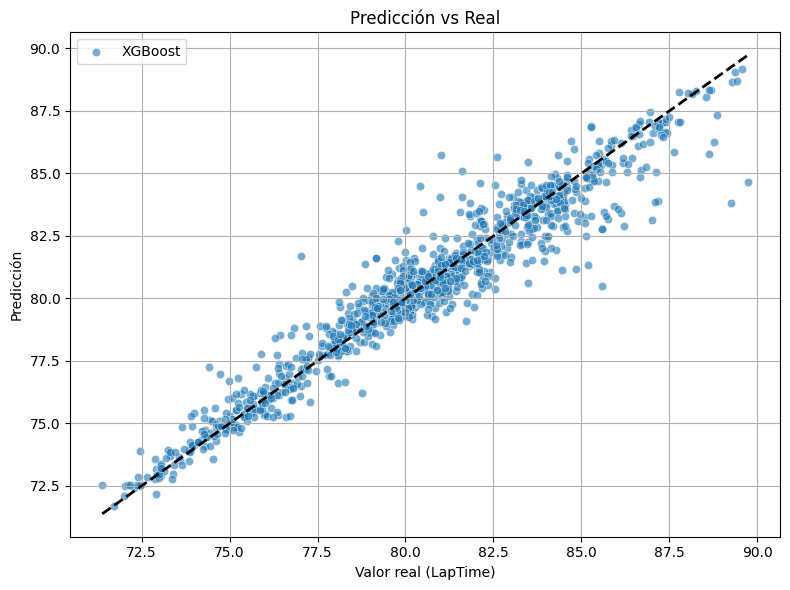

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test1, y=y_pred_xgb, label="XGBoost", alpha=0.6)
plt.plot([y_test1.min(), y_test1.max()], [
         y_test1.min(), y_test1.max()], 'k--', lw=2)
plt.xlabel("Valor real (LapTime)")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

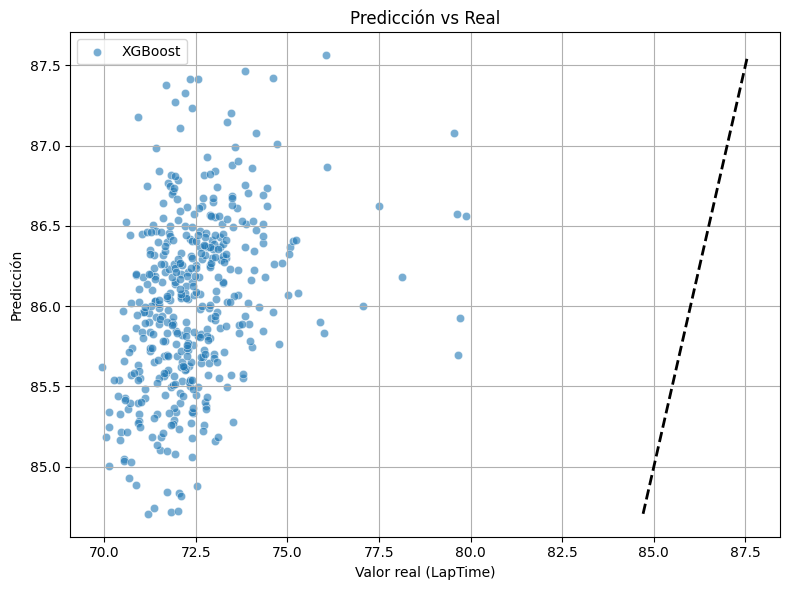

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_monaco, y=y_pred_xgb_monaco, label="XGBoost", alpha=0.6)
plt.plot([y_pred_xgb_monaco.min(), y_pred_xgb_monaco.max()], [
         y_pred_xgb_monaco.min(), y_pred_xgb_monaco.max()], 'k--', lw=2)
plt.xlabel("Valor real (LapTime)")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5.5 CatBoost

El siguiente modelo es CatBoost:

In [ ]:
# Modelo
cat_model = CatBoostRegressor(
    iterations=12000,
    learning_rate=0.008,
    depth=9,
    random_seed=42,
    loss_function='MAE',
    eval_metric='MAE',
    early_stopping_rounds=100,
    # subsample=0.85,
    bootstrap_type="Bayesian",
    bagging_temperature=0.5,
    verbose=True
)

cat_model.fit(
    X_train1, y_train1,
    eval_set=(X_val1, y_val1),
    cat_features=[X.columns.get_loc(c) for c in categorical_features]
)


# Predicciones
y_pred_cat = cat_model.predict(X_test1)

# Métricas
print("\nCatBoost:")
print(f"MAE:  {mean_absolute_error(y_test1, y_pred_cat):.4f}")
print(f"MSE:  {mean_squared_error(y_test1, y_pred_cat):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test1, y_pred_cat)):.4f}")
print(f"R²:   {r2_score(y_test1, y_pred_cat):.4f}")

Se han truncado las últimas 5000 líneas del flujo de salida.
3479:	learn: 0.3486415	test: 0.7137094	best: 0.7136961 (3477)	total: 2m 37s	remaining: 6m 26s
3480:	learn: 0.3486198	test: 0.7137089	best: 0.7136961 (3477)	total: 2m 37s	remaining: 6m 26s
3481:	learn: 0.3485827	test: 0.7136824	best: 0.7136824 (3481)	total: 2m 37s	remaining: 6m 26s
3482:	learn: 0.3485222	test: 0.7136753	best: 0.7136753 (3482)	total: 2m 37s	remaining: 6m 26s
3483:	learn: 0.3485064	test: 0.7136699	best: 0.7136699 (3483)	total: 2m 37s	remaining: 6m 26s
3484:	learn: 0.3484726	test: 0.7136783	best: 0.7136699 (3483)	total: 2m 38s	remaining: 6m 26s
3485:	learn: 0.3484452	test: 0.7136637	best: 0.7136637 (3485)	total: 2m 38s	remaining: 6m 26s
3486:	learn: 0.3483953	test: 0.7136631	best: 0.7136631 (3486)	total: 2m 38s	remaining: 6m 26s
3487:	learn: 0.3483734	test: 0.7136334	best: 0.7136334 (3487)	total: 2m 38s	remaining: 6m 26s
3488:	learn: 0.3483501	test: 0.7136304	best: 0.7136304 (3488)	total: 2m 38s	remaining: 6m 26s

In [ ]:
# Predicciones
y_pred_cat_monaco = cat_model.predict(X_monaco)

# Métricas
print("\nCatBoost:")
print(f"MAE:  {mean_absolute_error(y_monaco, y_pred_cat_monaco):.4f}")
print(f"MSE:  {mean_squared_error(y_monaco, y_pred_cat_monaco):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_monaco, y_pred_cat_monaco)):.4f}")
print(f"R²:   {r2_score(y_monaco, y_pred_cat_monaco):.4f}")


CatBoost:
MAE:  11.1116
MSE:  125.2186
RMSE: 11.1901
R²:   -61.2550


A continuación se muestra un grafo en el que se pueden ver las predicciones realizadas por el modelo en el subconjunto de test VS los valores reales de dicho subconjunto:

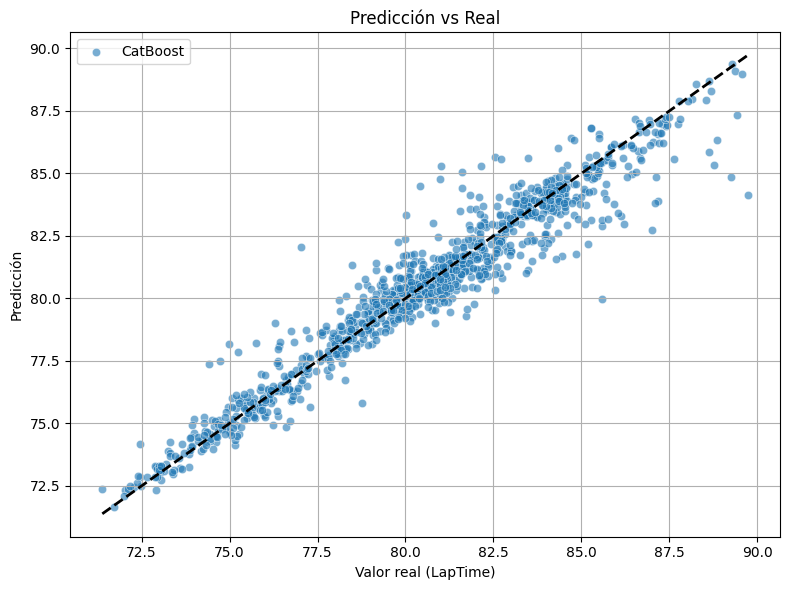

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test1, y=y_pred_cat, label="CatBoost", alpha=0.6)
plt.plot([y_test1.min(), y_test1.max()], [
         y_test1.min(), y_test1.max()], 'k--', lw=2)
plt.xlabel("Valor real (LapTime)")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

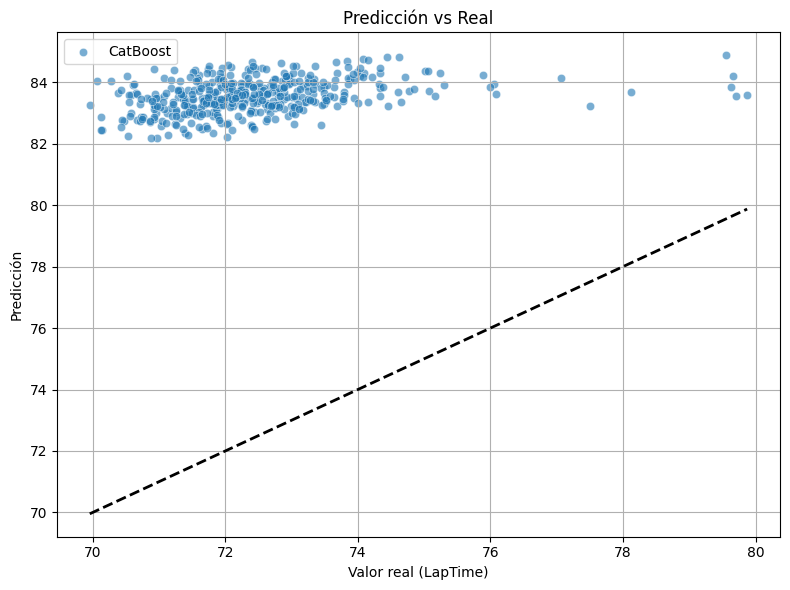

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_monaco, y=y_pred_cat_monaco, label="CatBoost", alpha=0.6)
plt.plot([y_monaco.min(), y_monaco.max()], [
         y_monaco.min(), y_monaco.max()], 'k--', lw=2)
plt.xlabel("Valor real (LapTime)")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5.4 LightGBM

El último modelo de la familia Boost que se ha querido utilizar para esta tarea es Light GBM, el cual utiliza también los pesos que se han utilizado en el modelo XGB:

In [ ]:
# LightGBM modelo
lgb_model = lgb.LGBMRegressor(
    objective="mae",
    n_estimators=15000,
    max_depth=10,
    learning_rate=0.003,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.4,
    reg_lambda=1.0,
    min_child_samples=8,
    min_split_gain=0.1,
    random_state=42
)

# Entrenamiento
lgb_model.fit(
    X_train1, y_train1,
    sample_weight=sample_weights,
    eval_set=[(X_val1, y_val1)],
    eval_metric="mae",
    callbacks=[early_stopping(stopping_rounds=100), log_evaluation(100)]
)

# Predicciones
y_pred_lgb = lgb_model.predict(X_test1)

print("\nLightGBM:")
print(f"MAE:  {mean_absolute_error(y_test1, y_pred_lgb):.4f}")
print(f"MSE:  {mean_squared_error(y_test1, y_pred_lgb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test1, y_pred_lgb)):.4f}")
print(f"R²:   {r2_score(y_test1, y_pred_lgb):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001231 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2878
[LightGBM] [Info] Number of data points in the train set: 4996, number of used features: 18
[LightGBM] [Info] Start training from score 80.748245
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 2.24516
[200]	valid_0's l1: 1.83867
[300]	valid_0's l1: 1.54072
[400]	valid_0's l1: 1.32122
[500]	valid_0's l1: 1.17038
[600]	valid_0's l1: 1.06367
[700]	valid_0's l1: 0.989294
[800]	valid_0's l1: 0.92839
[900]	valid_0's l1: 0.885299
[1000]	valid_0's l1: 0.854122
[1100]	valid_0's l1: 0.832512
[1200]	valid_0's l1: 0.817275
[1300]	valid_0's l1: 0.805019
[1400]	valid_0's l1: 0.794163
[1500]	valid_0's l1: 0.785822
[1600]	valid_0's l1: 0.777726
[1700]	valid_0's l1: 0.770228
[1800]	valid_0's l1: 0.764628
[1900]	valid_0's l1: 0.759842
[2000]	valid_0's l1: 0.755345
[2100]	valid

In [ ]:
# Predicciones
y_pred_lgb_monaco = lgb_model.predict(X_monaco)

print("\nLightGBM:")
print(f"MAE:  {mean_absolute_error(y_monaco, y_pred_lgb_monaco):.4f}")
print(f"MSE:  {mean_squared_error(y_monaco, y_pred_lgb_monaco):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_monaco, y_pred_lgb_monaco)):.4f}")
print(f"R²:   {r2_score(y_monaco, y_pred_lgb_monaco):.4f}")


LightGBM:
MAE:  12.4787
MSE:  157.4741
RMSE: 12.5489
R²:   -77.2915


A continuación se muestra un grafo en el que se pueden ver las predicciones realizadas por el modelo en el subconjunto de test VS los valores reales de dicho subconjunto:

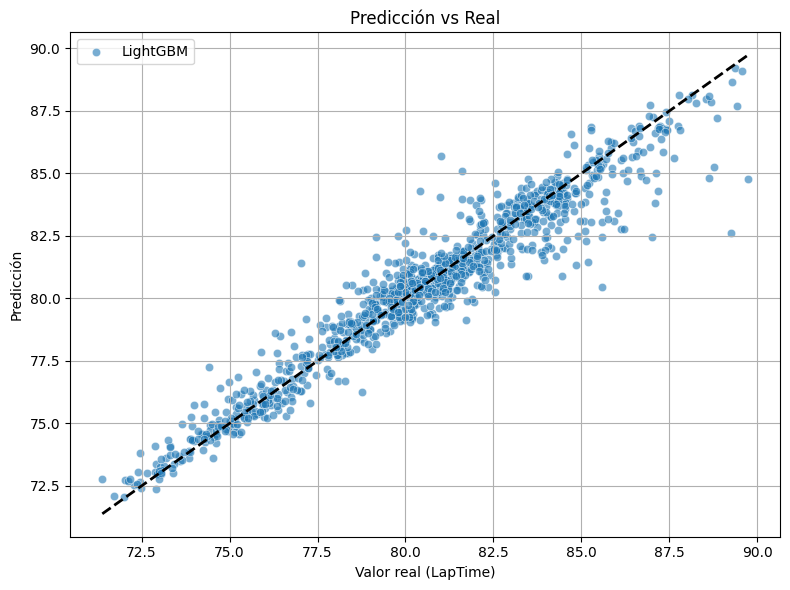

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test1, y=y_pred_lgb, label="LightGBM", alpha=0.6)
plt.plot([y_test1.min(), y_test1.max()], [
         y_test1.min(), y_test1.max()], 'k--', lw=2)
plt.xlabel("Valor real (LapTime)")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

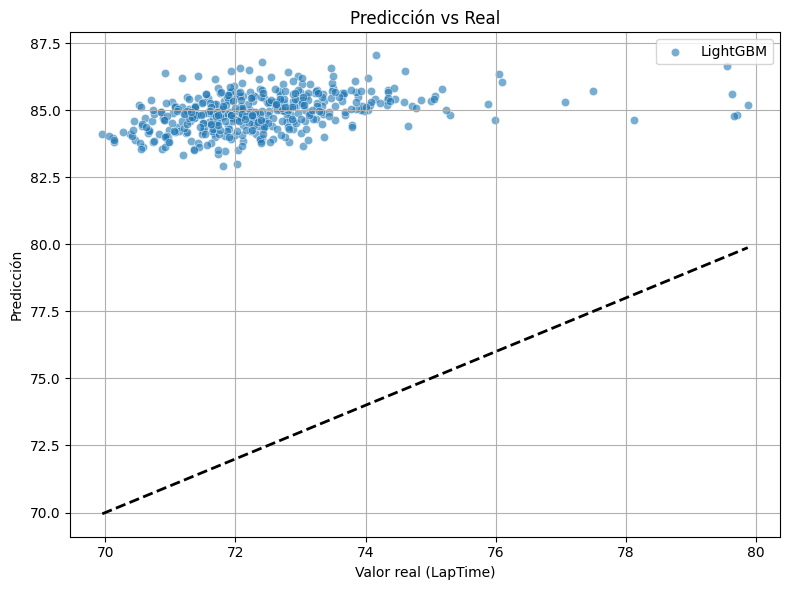

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_monaco, y=y_pred_lgb_monaco, label="LightGBM", alpha=0.6)
plt.plot([y_monaco.min(), y_monaco.max()], [
         y_monaco.min(), y_monaco.max()], 'k--', lw=2)
plt.xlabel("Valor real (LapTime)")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5.5 Red Neuronal en PyTorch

El siguiente modelo es una red neuronal de la librería PyTorch, este ha sido uno de los modelos más complejos de realizar:

In [ ]:
# Semilla


def set_seed_torch(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed_torch(42)

In [ ]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train1)
X_val_imp = imputer.transform(X_val1)
X_test_imp = imputer.transform(X_test1)

# Preprocesado
scaler_torch = StandardScaler()
X_train_scaled = scaler_torch.fit_transform(X_train_imp)
X_val_scaled = scaler_torch.transform(X_val_imp)
X_test_scaled = scaler_torch.transform(X_test_imp)

# Datasets
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(
    y_train1.values,
    dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val1.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test1.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [ ]:
# Modelo

class Net(nn.Module):
    def __init__(self, input_dim):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)


model = Net(input_dim=X_train1.shape[1])

# Loss y Optimizer
criterion = nn.L1Loss()  # MAE
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.2, patience=5)

# Entrenamiento
best_val_loss = np.inf
patience = 10
counter = 0

for epoch in range(200):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            val_losses.append(loss.item())

    val_loss = np.mean(val_losses)  # MAE
    scheduler.step(val_loss)

    # MAE
    print(
        f"Epoch {epoch+1} - Train Loss: {np.mean(train_losses):.4f} - Val Loss: {val_loss:.4f}")

    # EarlyStopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

# Cargar mejor modelo
model.load_state_dict(best_model_state)

# Predicción
model.eval()
with torch.no_grad():
    y_pred_pytorchnn = model(X_test_tensor).numpy()


print("PyTorch NN:")
print(f"MAE:  {mean_absolute_error(y_test_tensor, y_pred_pytorchnn):.4f}")
print(f"MSE:  {mean_squared_error(y_test_tensor, y_pred_pytorchnn):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_tensor, y_pred_pytorchnn)):.4f}")
print(f"R²:   {r2_score(y_test_tensor, y_pred_pytorchnn):.4f}")

Epoch 1 - Train Loss: 80.2761 - Val Loss: 80.3601
Epoch 2 - Train Loss: 79.7666 - Val Loss: 79.4815
Epoch 3 - Train Loss: 78.8449 - Val Loss: 78.5441
Epoch 4 - Train Loss: 77.6535 - Val Loss: 77.0131
Epoch 5 - Train Loss: 76.2001 - Val Loss: 75.6582
Epoch 6 - Train Loss: 74.5047 - Val Loss: 73.2937
Epoch 7 - Train Loss: 72.5742 - Val Loss: 71.9096
Epoch 8 - Train Loss: 70.4665 - Val Loss: 69.9487
Epoch 9 - Train Loss: 68.1167 - Val Loss: 67.2950
Epoch 10 - Train Loss: 65.5265 - Val Loss: 64.3031
Epoch 11 - Train Loss: 62.7497 - Val Loss: 61.1662
Epoch 12 - Train Loss: 59.7830 - Val Loss: 57.5091
Epoch 13 - Train Loss: 56.5285 - Val Loss: 55.2474
Epoch 14 - Train Loss: 53.1140 - Val Loss: 51.6796
Epoch 15 - Train Loss: 49.5300 - Val Loss: 47.5992
Epoch 16 - Train Loss: 45.6922 - Val Loss: 44.0824
Epoch 17 - Train Loss: 41.7011 - Val Loss: 39.3489
Epoch 18 - Train Loss: 37.4443 - Val Loss: 35.1037
Epoch 19 - Train Loss: 33.0064 - Val Loss: 30.4869
Epoch 20 - Train Loss: 28.4012 - Val Los

In [ ]:
X_test_imp_monaco = imputer.transform(X_monaco)
X_test_scaled_monaco = scaler_torch.transform(X_test_imp_monaco)
y_test_tensor_monaco = torch.tensor(y_monaco.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor_monaco = torch.tensor(X_test_scaled_monaco, dtype=torch.float32)

# Predicción
model.eval()
with torch.no_grad():
    y_pred_pytorchnn_monaco = model(X_test_tensor_monaco).numpy()


print("PyTorch NN:")
print(f"MAE:  {mean_absolute_error(y_test_tensor_monaco, y_pred_pytorchnn_monaco):.4f}")
print(f"MSE:  {mean_squared_error(y_test_tensor_monaco, y_pred_pytorchnn_monaco):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_tensor_monaco, y_pred_pytorchnn_monaco)):.4f}")
print(f"R²:   {r2_score(y_test_tensor_monaco, y_pred_pytorchnn_monaco):.4f}")

PyTorch NN:
MAE:  17.0014
MSE:  290.6732
RMSE: 17.0491
R²:   -143.5142


A continuación se muestra un grafo en el que se pueden ver las predicciones realizadas por el modelo en el subconjunto de test VS los valores reales de dicho subconjunto:

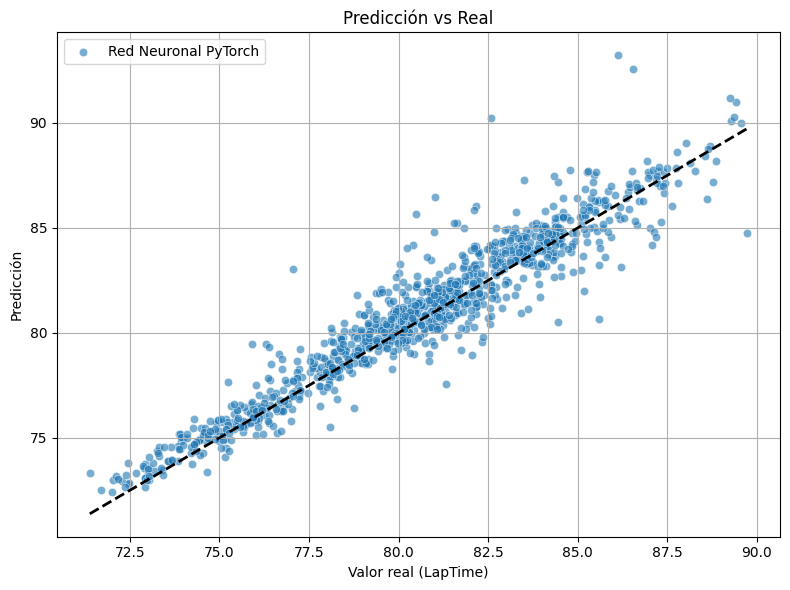

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=y_test1,
    y=y_pred_pytorchnn.ravel(),
    label="Red Neuronal PyTorch",
    alpha=0.6)
plt.plot([y_test1.min(), y_test1.max()], [
         y_test1.min(), y_test1.max()], 'k--', lw=2)
plt.xlabel("Valor real (LapTime)")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

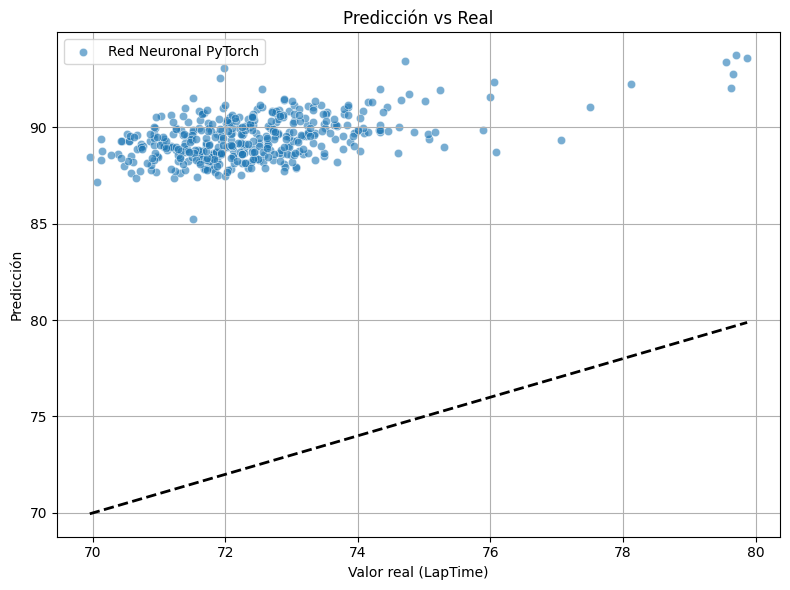

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=y_monaco,
    y=y_pred_pytorchnn_monaco.ravel(),
    label="Red Neuronal PyTorch",
    alpha=0.6)
plt.plot([y_monaco.min(), y_monaco.max()], [
         y_monaco.min(), y_monaco.max()], 'k--', lw=2)
plt.xlabel("Valor real (LapTime)")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5.6 Tabnet PyTorch

In [ ]:
scaler_tabnet = StandardScaler()
X_train_scaled_tabnet = scaler_tabnet.fit_transform(X_train_imp)
X_val_scaled_tabnet = scaler_tabnet.transform(X_val_imp)
X_test_scaled_tabnet = scaler_tabnet.transform(X_test_imp)

# TabNet modelo
tabnet_model = TabNetRegressor(
    n_d=64,
    n_a=64,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    lambda_sparse=5e-3,
    cat_idxs=[],
    cat_dims=[],
    cat_emb_dim=[],
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.001),
    scheduler_params={"step_size": 20, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    verbose=1,
    seed=42
)

tabnet_model.fit(
    X_train=X_train_scaled_tabnet,
    y_train=y_train1.values.reshape(-1, 1),
    eval_set=[(X_val_scaled_tabnet, y_val1.values.reshape(-1, 1))],
    eval_name=["val"],
    eval_metric=["mae"],
    max_epochs=300,
    patience=20,
    batch_size=512,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False,
)

# Predicciones:
y_pred_tabnet = tabnet_model.predict(X_test_scaled_tabnet)

# Evaluación
print("\nTabNet Pytorch:")
print(f"MAE:  {mean_absolute_error(y_test1, y_pred_tabnet):.4f}")
print(f"MSE:  {mean_squared_error(y_test1, y_pred_tabnet):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test1, y_pred_tabnet)):.4f}")
print(f"R²:   {r2_score(y_test1, y_pred_tabnet):.4f}")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 6912.67052| val_mae: 81.59888|  0:00:01s
epoch 1  | loss: 6509.1068| val_mae: 79.75204|  0:00:03s
epoch 2  | loss: 6134.62955| val_mae: 77.95596|  0:00:04s
epoch 3  | loss: 5816.23787| val_mae: 75.81111|  0:00:05s
epoch 4  | loss: 5478.02734| val_mae: 73.64425|  0:00:06s
epoch 5  | loss: 5167.42282| val_mae: 71.40926|  0:00:07s
epoch 6  | loss: 4882.87166| val_mae: 69.27771|  0:00:09s
epoch 7  | loss: 4607.43751| val_mae: 67.22369|  0:00:10s
epoch 8  | loss: 4333.48511| val_mae: 65.24932|  0:00:11s
epoch 9  | loss: 4056.32151| val_mae: 63.19183|  0:00:12s
epoch 10 | loss: 3772.44353| val_mae: 60.63273|  0:00:14s
epoch 11 | loss: 3514.78697| val_mae: 58.65301|  0:00:15s
epoch 12 | loss: 3272.50949| val_mae: 56.66963|  0:00:16s
epoch 13 | loss: 3045.98589| val_mae: 55.09769|  0:00:18s
epoch 14 | loss: 2812.99589| val_mae: 52.20927|  0:00:19s
epoch 15 | loss: 2565.40308| val_mae: 49.02526|  0:00:20s
epoch 16 | loss: 2287.15675| val_mae: 45.79694|  0:00:21s
epoch 17 | loss

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



TabNet Pytorch:
MAE:  1.1005
MSE:  2.1013
RMSE: 1.4496
R²:   0.8366


In [ ]:
X_test_scaled_tabnet_monaco = scaler_tabnet.transform(X_test_imp_monaco)
# Predicciones:
y_pred_tabnet_monaco = tabnet_model.predict(X_test_scaled_tabnet_monaco)

# Evaluación
print("\nTabNet Pytorch:")
print(f"MAE:  {mean_absolute_error(y_monaco, y_pred_tabnet_monaco):.4f}")
print(f"MSE:  {mean_squared_error(y_monaco, y_pred_tabnet_monaco):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_monaco, y_pred_tabnet_monaco)):.4f}")
print(f"R²:   {r2_score(y_monaco, y_pred_tabnet_monaco):.4f}")


TabNet Pytorch:
MAE:  819.0069
MSE:  2217680.3301
RMSE: 1489.1878
R²:   -1102564.1880


A continuación se muestra un grafo en el que se pueden ver las predicciones realizadas por el modelo en el subconjunto de test VS los valores reales de dicho subconjunto:

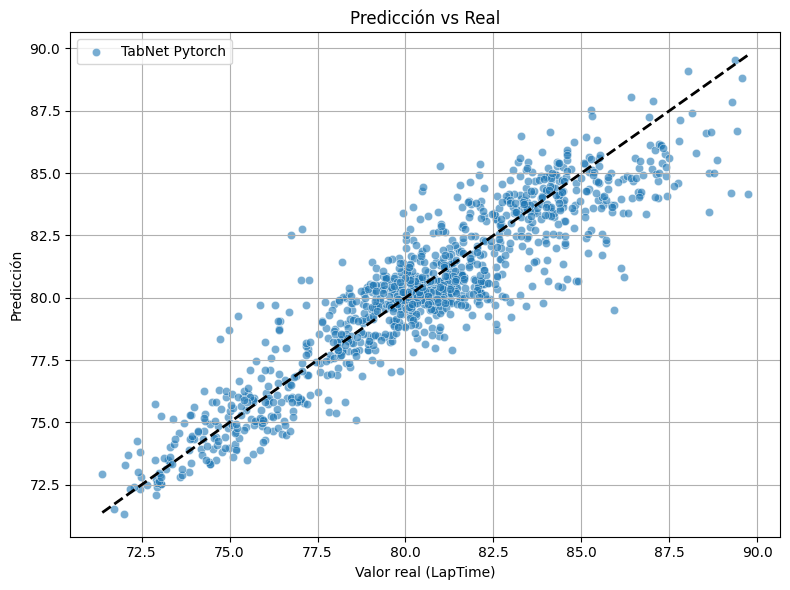

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=y_test1,
    y=y_pred_tabnet.ravel(),
    label="TabNet Pytorch",
    alpha=0.6)
plt.plot([y_test1.min(), y_test1.max()], [
         y_test1.min(), y_test1.max()], 'k--', lw=2)
plt.xlabel("Valor real (LapTime)")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

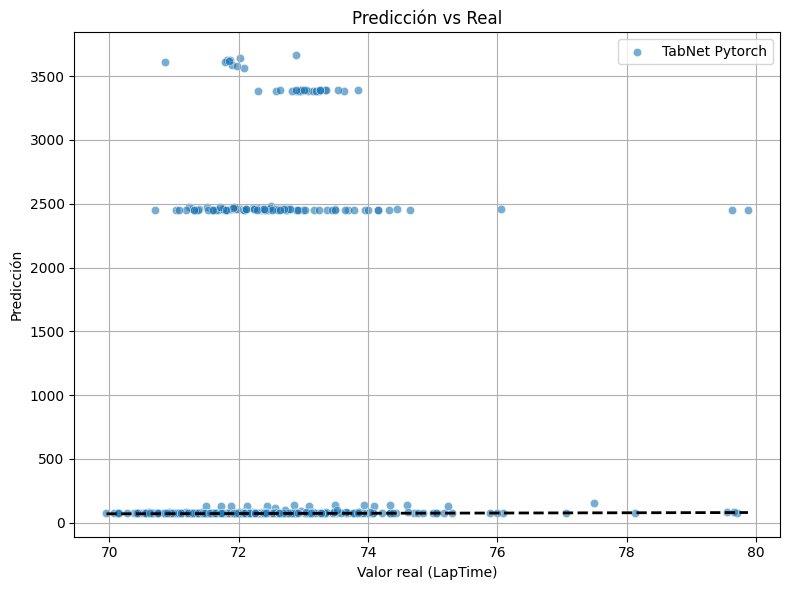

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=y_monaco,
    y=y_pred_tabnet_monaco.ravel(),
    label="TabNet Pytorch",
    alpha=0.6)
plt.plot([y_monaco.min(), y_monaco.max()], [
         y_monaco.min(), y_monaco.max()], 'k--', lw=2)
plt.xlabel("Valor real (LapTime)")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5.7 Red Neuronal en TensorFlow/Keras

El último modelo para esta tarea es una red neuronal de TensorFlow/Keras:

In [ ]:
def set_seed_keras(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)


set_seed_keras(42)

# Preprocesado
scaler_keras = StandardScaler()
X_train_scaled_keras = scaler_keras.fit_transform(X_train_imp)
X_val_scaled_keras = scaler_keras.transform(X_val_imp)
X_test_scaled_keras = scaler_keras.transform(X_test_imp)

# Learning Rate
optimizer = Adam(learning_rate=0.005)

model_keras_opt = Sequential([
    Input(shape=(X_train1.shape[1],)),
    Dense(128, activation='swish'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='swish'),
    BatchNormalization(),
    Dropout(0.15),
    Dense(32, activation='swish'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(16, activation='swish'),
    BatchNormalization(),
    Dense(1)
])

optimizer = AdamW(learning_rate=0.001)

model_keras_opt.compile(optimizer=optimizer, loss='mae', metrics=['mae'])

callbacks = [
    EarlyStopping(patience=20, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.7, patience=5, verbose=1)
]

history_opt = model_keras_opt.fit(
    X_train_scaled_keras, y_train1,
    validation_data=(X_val_scaled_keras, y_val1),
    epochs=300,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# Evaluación
y_pred_keras_opt = model_keras_opt.predict(X_test_scaled_keras, verbose=0)

print("Tensorflow/keras NN :")
print(f"MAE:  {mean_absolute_error(y_test1, y_pred_keras_opt):.4f}")
print(f"MSE:  {mean_squared_error(y_test1, y_pred_keras_opt):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test1, y_pred_keras_opt)):.4f}")
print(f"R²:   {r2_score(y_test1, y_pred_keras_opt):.4f}")

Epoch 1/300
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 80.3057 - mae: 80.3057 - val_loss: 80.7417 - val_mae: 80.7417 - learning_rate: 0.0010
Epoch 2/300
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 79.5290 - mae: 79.5290 - val_loss: 79.9252 - val_mae: 79.9252 - learning_rate: 0.0010
Epoch 3/300
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 78.2761 - mae: 78.2761 - val_loss: 78.5052 - val_mae: 78.5052 - learning_rate: 0.0010
Epoch 4/300
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 76.5198 - mae: 76.5198 - val_loss: 76.5680 - val_mae: 76.5680 - learning_rate: 0.0010
Epoch 5/300
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 74.2580 - mae: 74.2580 - val_loss: 74.1502 - val_mae: 74.1502 - learning_rate: 0.0010
Epoch 6/300
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 71.4973 - mae: 71.4973 - val_loss: 71.2399 - val_mae: 71.2399 - learning_rate: 0.0010
Epoch 7/300
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 68.2474 - mae: 68.2474 - val_loss: 67.6804 - val_mae: 67.6804 - learn

In [ ]:
X_test_scaled_keras_monaco = scaler_keras.transform(X_test_imp_monaco)
# Evaluación
y_pred_keras_opt_monaco = model_keras_opt.predict(X_test_scaled_keras_monaco, verbose=0)

print("Tensorflow/keras NN :")
print(f"MAE:  {mean_absolute_error(y_monaco, y_pred_keras_opt_monaco):.4f}")
print(f"MSE:  {mean_squared_error(y_monaco, y_pred_keras_opt_monaco):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_monaco, y_pred_keras_opt_monaco)):.4f}")
print(f"R²:   {r2_score(y_monaco, y_pred_keras_opt_monaco):.4f}")

Tensorflow/keras NN :
MAE:  18.0607
MSE:  326.9554
RMSE: 18.0819
R²:   -161.5526


A continuación se muestra un grafo en el que se pueden ver las predicciones realizadas por el modelo en el subconjunto de test VS los valores reales de dicho subconjunto:

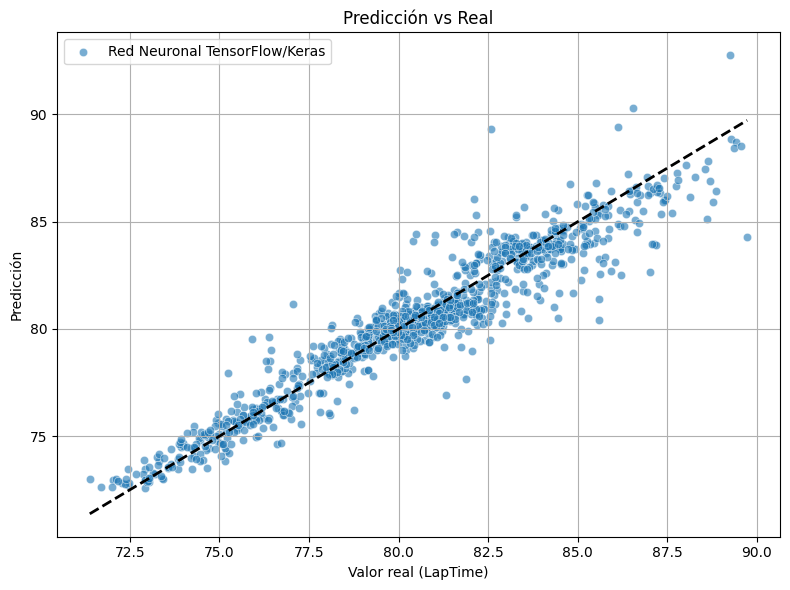

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=y_test1,
    y=y_pred_keras_opt.ravel(),
    label="Red Neuronal TensorFlow/Keras",
    alpha=0.6)
plt.plot([y_test1.min(), y_test1.max()], [
         y_test1.min(), y_test1.max()], 'k--', lw=2)
plt.xlabel("Valor real (LapTime)")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

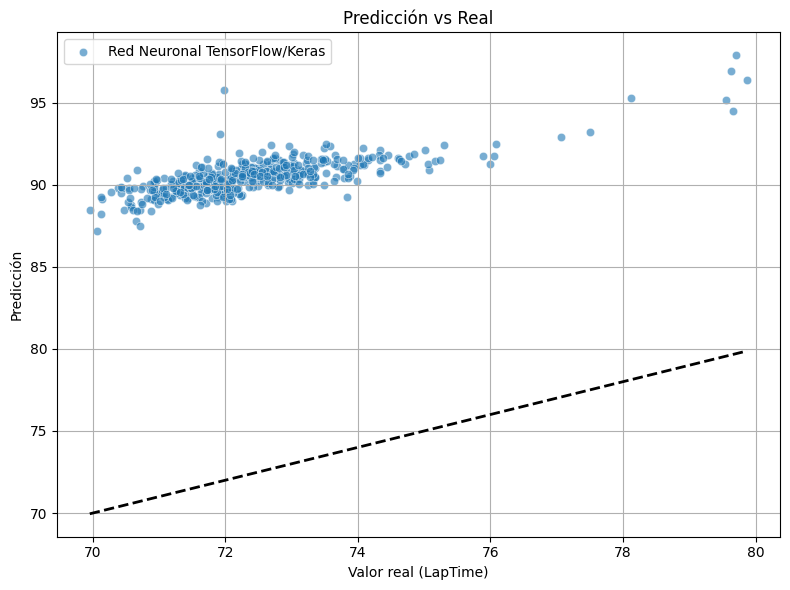

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=y_monaco,
    y=y_pred_keras_opt_monaco.ravel(),
    label="Red Neuronal TensorFlow/Keras",
    alpha=0.6)
plt.plot([y_monaco.min(), y_monaco.max()], [
         y_monaco.min(), y_monaco.max()], 'k--', lw=2)
plt.xlabel("Valor real (LapTime)")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5.8 Dummy Regressor

A continuación se ha realizado un modelo Dummy para que sirva de base en las comparaciones a realizar entre los modelos:

In [ ]:
# Creamos y entrenamos
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train1, y_train1)

# Predicciones
y_pred_dummy = dummy.predict(X_test1)

# Métricas Dummy
dummy_mae = mean_absolute_error(y_test1, y_pred_dummy)
dummy_mse = mean_squared_error(y_test1, y_pred_dummy)
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(y_test1, y_pred_dummy)

print("Dummy Regressor:")
print(f"MAE:  {dummy_mae:.4f}")
print(f"MSE:  {dummy_mse:.4f}")
print(f"RMSE: {dummy_rmse:.4f}")
print(f"R²:   {dummy_r2:.4f}")
# Predicciones Monaco
y_pred_dummy_monaco = dummy.predict(X_monaco)

# Métricas Dummy
dummy_mae = mean_absolute_error(y_monaco, y_pred_dummy_monaco)
dummy_mse = mean_squared_error(y_monaco, y_pred_dummy_monaco)
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(y_monaco, y_pred_dummy_monaco)

print("Dummy Regressor:")
print(f"MAE:  {dummy_mae:.4f}")
print(f"MSE:  {dummy_mse:.4f}")
print(f"RMSE: {dummy_rmse:.4f}")
print(f"R²:   {dummy_r2:.4f}")

Dummy Regressor:
MAE:  2.8218
MSE:  12.8615
RMSE: 3.5863
R²:   -0.0000
Dummy Regressor:
MAE:  8.1134
MSE:  67.8394
RMSE: 8.2365
R²:   -32.7277


# 6.Tarea 2 Clasificación del compuesto de neumático

La métrica princial de esta tarea es el **F1-Score**, pues buscamos un buen balance entre precision y recall. Debido a esto, buscaremos minimizar tanto los falsos positivos como los falsos negativos que puedan presentar los modelos.

## 6.1 Preprocesado de la tarea

Al igual que en la tarea anterior, primero copiamos el dataset original antes de realizar el preprocesado específico de la tarea:

In [ ]:
df_tarea2 = df_original.copy()

Rellenamos las columnas numéricas con NaNs con la media por Compound:

In [ ]:
columnas_con_nans = [
    'SpeedI1',
    'SpeedFL',
    'SpeedST',
    'SpeedDiff',
    'SpeedFL_norm']
for col in columnas_con_nans:
    df_tarea2[col] = df_tarea2.groupby(
        'Compound')[col].transform(lambda x: x.fillna(x.mean()))

Vamos a crear 2 nuevas features para nuestra tarea de clasificación, la velocidad media y la degradación del neumático:

In [ ]:
df_tarea2['AverageSpeed'] = df_tarea2[['SpeedI1',
                                       'SpeedI2', 'SpeedFL', 'SpeedST']].mean(axis=1)
df_tarea2['TyreDegradation'] = df_tarea2['TyreLife'] / \
    (df_tarea2['TyreAgeRatio'] + 1e-6)  # Para evitar división por 0

Finalmente eliminaremos columnas inútiles, con información repetida o que den mucha información:

In [ ]:
df_tarea2.drop(
    columns=[
        'LapStartTime',
        'Time'],
    inplace=True)

Veamos cómo queda nuestro dataset:

In [ ]:
df_tarea2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8289 entries, 2 to 10261
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DriverNumber     8289 non-null   float64
 1   LapNumber        8289 non-null   float64
 2   Stint            8286 non-null   float64
 3   SpeedI1          8289 non-null   float64
 4   SpeedI2          8289 non-null   float64
 5   SpeedFL          8289 non-null   float64
 6   SpeedST          8289 non-null   float64
 7   IsPersonalBest   8289 non-null   float64
 8   Compound         8289 non-null   float64
 9   TyreLife         8274 non-null   float64
 10  FreshTyre        8289 non-null   int64  
 11  Team             8289 non-null   float64
 12  TrackStatus      8289 non-null   float64
 13  LapTime(s)       8289 non-null   float64
 14  GP               8289 non-null   float64
 15  CircuitDistance  8289 non-null   float64
 16  Year             8289 non-null   int64  
 17  Session          8

In [ ]:
df_tarea2_monaco = df_monaco.copy()
for col in columnas_con_nans:
    df_tarea2_monaco[col] = df_tarea2_monaco.groupby(
        'Compound')[col].transform(lambda x: x.fillna(x.mean()))
df_tarea2_monaco['AverageSpeed'] = df_tarea2_monaco[['SpeedI1',
                                       'SpeedI2', 'SpeedFL', 'SpeedST']].mean(axis=1)
df_tarea2_monaco['TyreDegradation'] = df_tarea2_monaco['TyreLife'] / \
    (df_tarea2_monaco['TyreAgeRatio'] + 1e-6)  # Para evitar división por 0
df_tarea2_monaco.drop(
    columns=[
        'LapStartTime',
        'Time'],
    inplace=True)
df_tarea2_monaco.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1031 entries, 0 to 1277
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DriverNumber     1031 non-null   float64
 1   LapNumber        1031 non-null   float64
 2   Stint            1031 non-null   float64
 3   SpeedI1          1031 non-null   float64
 4   SpeedI2          1031 non-null   float64
 5   SpeedFL          1031 non-null   float64
 6   SpeedST          1031 non-null   float64
 7   IsPersonalBest   1031 non-null   int64  
 8   Compound         1031 non-null   float64
 9   TyreLife         1031 non-null   float64
 10  FreshTyre        1031 non-null   int64  
 11  Team             1031 non-null   float64
 12  TrackStatus      1031 non-null   float64
 13  LapTime(s)       1031 non-null   float64
 14  CircuitDistance  1031 non-null   float64
 15  Year             1031 non-null   int64  
 16  Session          1031 non-null   float64
 17  GP               10

## 6.2 División Train Test Validación

Primero dividimos entre features y target:

In [ ]:
features = [
    'LapNumber',
    'Stint',
    'SpeedI1',
    'SpeedI2',
    'SpeedFL',
    'SpeedST',
    'TyreLife',
    'FreshTyre',
    'Year',
    'LapTime(s)',
    'SpeedDiff',
    'TyreAgeRatio',
    'SpeedFL_norm',
    'Team',
    'TrackStatus',
    'Session',
    'AverageSpeed',
    'TyreDegradation',
    'GP',
    'CircuitDistance',
    'DriverNumber',
    'IsPersonalBest']

target = 'Compound'

Ahora dividimos entre X e Y:

In [ ]:
X = df_tarea2[features]
y = df_tarea2[target]
X_monaco_2 = df_tarea2_monaco[features]
y_monaco_2 = df_tarea2_monaco[target]

División entre train 70%, test 15% y validación 15%:

In [ ]:
# Primero separamos train del resto
train_df2, temp_df2 = train_test_split(
    df_tarea2,
    test_size=0.3,
    random_state=42,
    shuffle=True
)
# Luego separamos validación y test
val_df2, test_df2 = train_test_split(
    temp_df2,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

# Comprobamos tamaños
print(f'Tamaño Train: {len(train_df2)}')
print(f'Tamaño Validación: {len(val_df2)}')
print(f'Tamaño Test: {len(test_df2)}')

Tamaño Train: 5802
Tamaño Validación: 1243
Tamaño Test: 1244


Dividimos cada subconjunto en X e Y:

In [ ]:
y_train2 = train_df2['Compound']
X_train2 = train_df2.drop(columns=['Compound'])
feature_order = X_train2.columns.tolist()
X_monaco_2 = df_tarea2_monaco.reindex(columns=feature_order)

y_val2 = val_df2['Compound']
X_val2 = val_df2.drop(columns=['Compound'])

y_test2 = test_df2['Compound']
X_test2 = test_df2.drop(columns=['Compound'])

In [ ]:
# Comprobamos tamaños
print(f'Tamaño Y_Train: {len(y_train2)}')
print(f'Tamaño X_Train: {len(X_train2)}')
print(f'Tamaño Y_Validación: {len(y_val2)}')
print(f'Tamaño X_Validación: {len(X_val2)}')
print(f'Tamaño Y_Test: {len(y_test2)}')
print(f'Tamaño X_Test: {len(X_test2)}')

Tamaño Y_Train: 5802
Tamaño X_Train: 5802
Tamaño Y_Validación: 1243
Tamaño X_Validación: 1243
Tamaño Y_Test: 1244
Tamaño X_Test: 1244


Escalado de los datos para los modelos que lo necesiten o mejoren con ello:

In [ ]:
imputer = SimpleImputer(strategy="median")
X_train_imp_2 = imputer.fit_transform(X_train2)
X_val_imp_2 = imputer.transform(X_val2)
X_test_imp_2 = imputer.transform(X_test2)
X_monaco_imp_2 = imputer.transform(X_monaco_2)

scaler = StandardScaler()

# Transformar train validación y test con el mismo scaler
X_train_scaled2 = scaler.fit_transform(X_train_imp_2)
X_val_scaled2 = scaler.transform(X_val_imp_2)
X_test_scaled2 = scaler.transform(X_test_imp_2)
X_train_escaled_monaco = scaler.fit_transform(X_monaco_imp_2)

Función para evaluar los modelos, en ella se utilizan diferentes métricas que nos servirán para evaluar a todos nuestros modelos de clasificación:

In [ ]:
# Evaluación de los modelos


def evaluate_model(y_true, y_pred, model_name):
    print(f"\nEvaluación del modelo {model_name}:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(
        f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1-Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}\n")

## 6.3 Random Forest Classifier

El primer modelo de nuestra tarea de clasificación en un Random Forest, al cual se le han modificado bastante los hiper parámetros para tratar de obtener el mejor resultado posible:

In [ ]:
X_train_combined2 = pd.concat([X_train2, X_val2], axis=0)
y_train_combined2 = np.concatenate((y_train2, y_val2), axis=0)

rf_clf = RandomForestClassifier(
    n_estimators=3000,
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_combined2, y_train_combined2)

y_pred_rf = rf_clf.predict(X_test2)

evaluate_model(y_test2, y_pred_rf, "Random Forest")


Evaluación del modelo Random Forest:
Accuracy: 0.8553
Precision: 0.8541
Recall: 0.8553
F1-Score: 0.8534
Confusion Matrix:
[[  2   0   0   0   0   0]
 [  0 148   0  26  12   0]
 [  0   0  12   0   4   0]
 [  0  17   0 250  66   2]
 [  0   9   0  35 630   0]
 [  0   4   0   2   3  22]]



In [ ]:
y_pred_rf_monaco = rf_clf.predict(X_monaco_2)

evaluate_model(y_monaco_2, y_pred_rf_monaco, "Random Forest")


Evaluación del modelo Random Forest:
Accuracy: 0.8157
Precision: 0.9201
Recall: 0.8157
F1-Score: 0.8636
Confusion Matrix:
[[  0   0   0]
 [  0   5  37]
 [ 18 135 836]]



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 6.4 LGBM Classifier

Viendo el buen rendimiento de LGBM para la tarea de regresión, se ha querido probar su rendimiento en esta tarea de clasificación:

In [ ]:
model_lgbm = LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=20000,
    learning_rate=0.005,
    max_depth=10,
    num_leaves=7,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42
)

# Entrenamiento
model_lgbm.fit(
    X_train2, y_train2,
    eval_set=[(X_val2, y_val2)],
    eval_metric='logloss',
    callbacks=[early_stopping(stopping_rounds=100),
               log_evaluation(100)]
)

y_pred_lgbm = model_lgbm.predict(X_test2)

evaluate_model(y_test2, y_pred_lgbm, "LGBM")

Se han truncado las últimas 5000 líneas del flujo de salida.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [ ]:
y_pred_lgbm_monaco = model_lgbm.predict(X_monaco_2)

evaluate_model(y_monaco_2, y_pred_lgbm_monaco, "LGBM")


Evaluación del modelo LGBM:
Accuracy: 0.8497
Precision: 0.9183
Recall: 0.8497
F1-Score: 0.8824
Confusion Matrix:
[[  0   0   0   0]
 [  0   0   0   0]
 [  0   0   2  40]
 [  6  27  82 874]]



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 6.5 XGBoost

Al igual que en el modelo anterior, se ha querido comprobar si XGBoost volverá a ser de los favoritos en esta segunda tarea:

In [ ]:
xgb_clf = XGBClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=20000,
    learning_rate=0.003,
    max_depth=10,
    colsample_bytree=0.8,
    subsample=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    early_stopping_rounds=100,
    random_state=42
)

xgb_clf.fit(
    X_train2, y_train2,
    eval_set=[(X_val2, y_val2)],
    verbose=True
)
y_pred_xgb = xgb_clf.predict(X_test2)

evaluate_model(y_test2, y_pred_xgb, "XGB")

Se han truncado las últimas 5000 líneas del flujo de salida.
[5298]	validation_0-mlogloss:0.20747
[5299]	validation_0-mlogloss:0.20746
[5300]	validation_0-mlogloss:0.20745
[5301]	validation_0-mlogloss:0.20744
[5302]	validation_0-mlogloss:0.20745
[5303]	validation_0-mlogloss:0.20744
[5304]	validation_0-mlogloss:0.20744
[5305]	validation_0-mlogloss:0.20743
[5306]	validation_0-mlogloss:0.20741
[5307]	validation_0-mlogloss:0.20740
[5308]	validation_0-mlogloss:0.20741
[5309]	validation_0-mlogloss:0.20740
[5310]	validation_0-mlogloss:0.20740
[5311]	validation_0-mlogloss:0.20740
[5312]	validation_0-mlogloss:0.20740
[5313]	validation_0-mlogloss:0.20739
[5314]	validation_0-mlogloss:0.20740
[5315]	validation_0-mlogloss:0.20740
[5316]	validation_0-mlogloss:0.20740
[5317]	validation_0-mlogloss:0.20739
[5318]	validation_0-mlogloss:0.20739
[5319]	validation_0-mlogloss:0.20738
[5320]	validation_0-mlogloss:0.20737
[5321]	validation_0-mlogloss:0.20737
[5322]	validation_0-mlogloss:0.20736
[5323]	validat

In [ ]:
y_pred_xgb_monaco = xgb_clf.predict(X_monaco_2)

evaluate_model(y_monaco_2, y_pred_xgb_monaco, "XGB")


Evaluación del modelo XGB:
Accuracy: 0.8846
Precision: 0.9216
Recall: 0.8846
F1-Score: 0.9025
Confusion Matrix:
[[  0   0   0]
 [  0   3  39]
 [ 14  66 909]]



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 6.6 KNN

También se ha querido probar un modelo más clásico, el cual no tiene tantos hiper parámetros que se puedan ajustar, pero es una forma diferente de afrontar esta tarea:

In [ ]:
X_train_combined2 = pd.concat([X_train2, X_val2], axis=0)
y_train_combined2 = np.concatenate((y_train2, y_val2), axis=0)
X_combined2 = imputer.fit_transform(X_train_combined2)
X_train_combined_scaled2 = scaler.transform(X_combined2)

knn_clf = KNeighborsClassifier(
    n_neighbors=10,
    leaf_size=50,
    algorithm='auto',
    weights='distance',
    metric='minkowski',
    p=1
)

knn_clf.fit(
    X_train_combined_scaled2, y_train_combined2
)

y_pred_knn = knn_clf.predict(X_test_scaled2)

evaluate_model(y_test2, y_pred_knn, "KNN")


Evaluación del modelo KNN:
Accuracy: 0.5378
Precision: 0.5164
Recall: 0.5378
F1-Score: 0.4498
Confusion Matrix:
[[  0   0   0   0   2   0]
 [  0   6  13  41 125   1]
 [  0   0   0   0  16   0]
 [  0   4   7  47 277   0]
 [  0   0  35  21 616   2]
 [  0   0   0   3  28   0]]



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_pred_knn_monaco = knn_clf.predict(X_train_escaled_monaco)

evaluate_model(y_monaco_2, y_pred_knn_monaco, "KNN")


Evaluación del modelo KNN:
Accuracy: 0.8371
Precision: 0.9161
Recall: 0.8371
F1-Score: 0.8746
Confusion Matrix:
[[  0   0   0   0]
 [  0   0   0   0]
 [  0   0   1  41]
 [  7  18 102 862]]



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 6.7 MLP Classifier

A continuación nos encontramos con un modelo MLP Classifier de Sklearn:

In [ ]:
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(100, 100),
    max_iter=4000,
    activation='tanh',
    solver='adam',
    alpha=0.005,
    random_state=42
)

mlp_clf.fit(X_train_scaled2, y_train2)
y_pred_mlp = mlp_clf.predict(X_test_scaled2)

evaluate_model(y_test2, y_pred_mlp, "MLP Sklearn")


Evaluación del modelo MLP Sklearn:
Accuracy: 0.8971
Precision: 0.8969
Recall: 0.8971
F1-Score: 0.8966
Confusion Matrix:
[[  1   0   0   1   0   0]
 [  0 153   0  25   8   0]
 [  0   0  11   0   5   0]
 [  0  27   0 281  24   3]
 [  0   3   1  23 643   4]
 [  0   1   0   1   2  27]]



In [ ]:
y_pred_mlp_monaco = mlp_clf.predict(X_train_escaled_monaco)

evaluate_model(y_monaco_2, y_pred_mlp_monaco, "MLP Sklearn")


Evaluación del modelo MLP Sklearn:
Accuracy: 0.4306
Precision: 0.8998
Recall: 0.4306
F1-Score: 0.5726
Confusion Matrix:
[[  0   0   0   0   0   0]
 [  0   0   0   0   0   0]
 [  0   0   0   0   0   0]
 [  0   0   0  13  29   0]
 [  1  61   1 493 431   2]
 [  0   0   0   0   0   0]]



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 6.8 MLPClassifier Keras

Finalmente, como último modelo se ha querido utilizar un MLP de Keras, para comparar cual de los dos modelos MLP obtiene mejores resultados:

Primero definimos las configuraciones de Early Stopping y de Reducción de la tasa de aprendizaje:

In [ ]:
# Configucion EarlyStopping
early_stopping_keras = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# Configucion ReduceLROnPlateau
reduce_lr_keras = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
)

Finalmente definimos el modelo, lo entrenamos y lo evaluamos:

In [ ]:
seed = 42
tf.random.set_seed(seed)
random.seed(seed)
np.random.seed(seed)

model_keras_class = keras.Sequential([
    layers.Input(shape=(X_train_scaled2.shape[1],)),
    layers.Dense(100, activation='tanh'),
    layers.Dense(100, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(32, activation='tanh'),
    layers.Dense(len(np.unique(y_train2)), activation='softmax')
])

model_keras_class.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar el modelo
history = model_keras_class.fit(
    X_train_scaled2,
    y_train2,
    epochs=150,
    batch_size=32,
    validation_data=(X_val_scaled2, y_val2),
    callbacks=[early_stopping_keras, reduce_lr_keras],
    verbose=1
)

# Evaluar el modelo
y_pred_probs = model_keras_class.predict(X_test_scaled2)
y_pred_mlp_keras = np.argmax(y_pred_probs, axis=1)

evaluate_model(y_test2, y_pred_mlp_keras, "MLP Keras")

Epoch 1/150
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6553 - loss: 0.8596 - val_accuracy: 0.6983 - val_loss: 0.7114 - learning_rate: 0.0050
Epoch 2/150
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7204 - loss: 0.6926 - val_accuracy: 0.7353 - val_loss: 0.6454 - learning_rate: 0.0050
Epoch 3/150
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7472 - loss: 0.6246 - val_accuracy: 0.7667 - val_loss: 0.6089 - learning_rate: 0.0050
Epoch 4/150
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7651 - loss: 0.5740 - val_accuracy: 0.7868 - val_loss: 0.5346 - learning_rate: 0.0050
Epoch 5/150
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7868 - loss: 0.5262 - val_accuracy: 0.8093 - val_loss: 0.5058 - learning_rate: 0.0050
Epoch 6/150
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8037 - loss: 0.4773 - val_accuracy: 0.8150 - val_loss: 0.4848 - learning_rate: 0.0050
Epoch 7/150
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8166 - loss: 0.

In [ ]:
# Evaluar el modelo
y_pred_probs_monaco = model_keras_class.predict(X_train_escaled_monaco)
y_pred_mlp_keras_monaco = np.argmax(y_pred_probs_monaco, axis=1)

evaluate_model(y_monaco_2, y_pred_mlp_keras_monaco, "MLP Keras")

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Evaluación del modelo MLP Keras:
Accuracy: 0.4365
Precision: 0.9065
Recall: 0.4365
F1-Score: 0.5794
Confusion Matrix:
[[  0   0   0   0   0   0]
 [  0   0   0   0   0   0]
 [  0   0   0   0   0   0]
 [  0   3   0  13  26   0]
 [  1  44   1 474 437  32]
 [  0   0   0   0   0   0]]



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 6.9 Dummy Classifier

A continuación se ha realizado un modelo Dummy para que sirva de base en las comparaciones a realizar entre los modelos:

In [ ]:
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train_scaled2, y_train2)
y_pred_dummy_clf = dummy_clf.predict(X_test_scaled2)
evaluate_model(y_test2, y_pred_dummy_clf, "Dummy CLF")
y_pred_dummy_clf = dummy_clf.predict(X_train_escaled_monaco)
evaluate_model(y_monaco_2, y_pred_dummy_clf, "Dummy CLF")


Evaluación del modelo Dummy CLF:
Accuracy: 0.5418
Precision: 0.2935
Recall: 0.5418
F1-Score: 0.3808
Confusion Matrix:
[[  0   0   0   0   2   0]
 [  0   0   0   0 186   0]
 [  0   0   0   0  16   0]
 [  0   0   0   0 335   0]
 [  0   0   0   0 674   0]
 [  0   0   0   0  31   0]]


Evaluación del modelo Dummy CLF:
Accuracy: 0.9593
Precision: 0.9202
Recall: 0.9593
F1-Score: 0.9393
Confusion Matrix:
[[  0  42]
 [  0 989]]



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
